# EDA

## 임포트 및 기본설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import platform
import os
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1) 한글 폰트 설정
# ============================================================
def set_korean_font():
    system = platform.system()
    
    if system == 'Windows':
        candidates = ['C:/Windows/Fonts/malgun.ttf', 'C:/Windows/Fonts/NanumGothic.ttf']
    elif system == 'Darwin':
        candidates = ['/System/Library/Fonts/AppleSDGothicNeo.ttc', '/Library/Fonts/NanumGothic.ttf']
    else:
        candidates = ['/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
                      '/usr/share/fonts/nanum/NanumGothic.ttf']
    
    for path in candidates:
        if os.path.exists(path):
            prop = fm.FontProperties(fname=path)
            plt.rcParams['font.family'] = prop.get_name()
            plt.rcParams['axes.unicode_minus'] = False
            print(f"✅ 폰트 설정 완료: {path}")
            return prop
    
    # Colab
    try:
        os.system('apt-get install -y fonts-nanum > /dev/null 2>&1')
        path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
        if os.path.exists(path):
            prop = fm.FontProperties(fname=path)
            plt.rcParams['font.family'] = prop.get_name()
            plt.rcParams['axes.unicode_minus'] = False
            fm._load_fontmanager(try_read_cache=False)
            print("✅ Colab 나눔고딕 설치 완료")
            return prop
    except:
        pass
    
    print("⚠️ 한글 폰트 없음 — 기본 폰트 사용")
    return None

fp = set_korean_font()
fp_kw = {'fontproperties': fp} if fp else {}

# ============================================================
# pandas / numpy 출력 제한 해제
# ============================================================
pd.set_option('display.max_rows', None)          # 행 제한 해제
pd.set_option('display.max_columns', None)        # 열 제한 해제
pd.set_option('display.max_colwidth', None)       # 셀 내 문자열 길이 제한 해제
pd.set_option('display.width', None)              # 출력 너비 제한 해제
pd.set_option('display.max_info_columns', 200)    # info() 출력 제한 해제
np.set_printoptions(threshold=np.inf)             # numpy 배열 출력 제한 해제

✅ 폰트 설정 완료: C:/Windows/Fonts/malgun.ttf


## 데이터 로드

In [2]:
# ============================================================
# 2) 데이터 로드
# ============================================================
train = pd.read_csv('../data/train.csv')
TARGET = '임신 성공 여부'

print(f"데이터 크기: {train.shape}")
print(f"컬럼 수: {train.shape[1]}")
print(f"\n타겟 분포:\n{train[TARGET].value_counts()}")
print(f"\n타겟 비율:\n{train[TARGET].value_counts(normalize=True).round(4)}")

데이터 크기: (256351, 69)
컬럼 수: 69

타겟 분포:
임신 성공 여부
0    190123
1     66228
Name: count, dtype: int64

타겟 비율:
임신 성공 여부
0    0.7417
1    0.2583
Name: proportion, dtype: float64


## EDA Part 1 - 기본 통계 & 타겟 분포

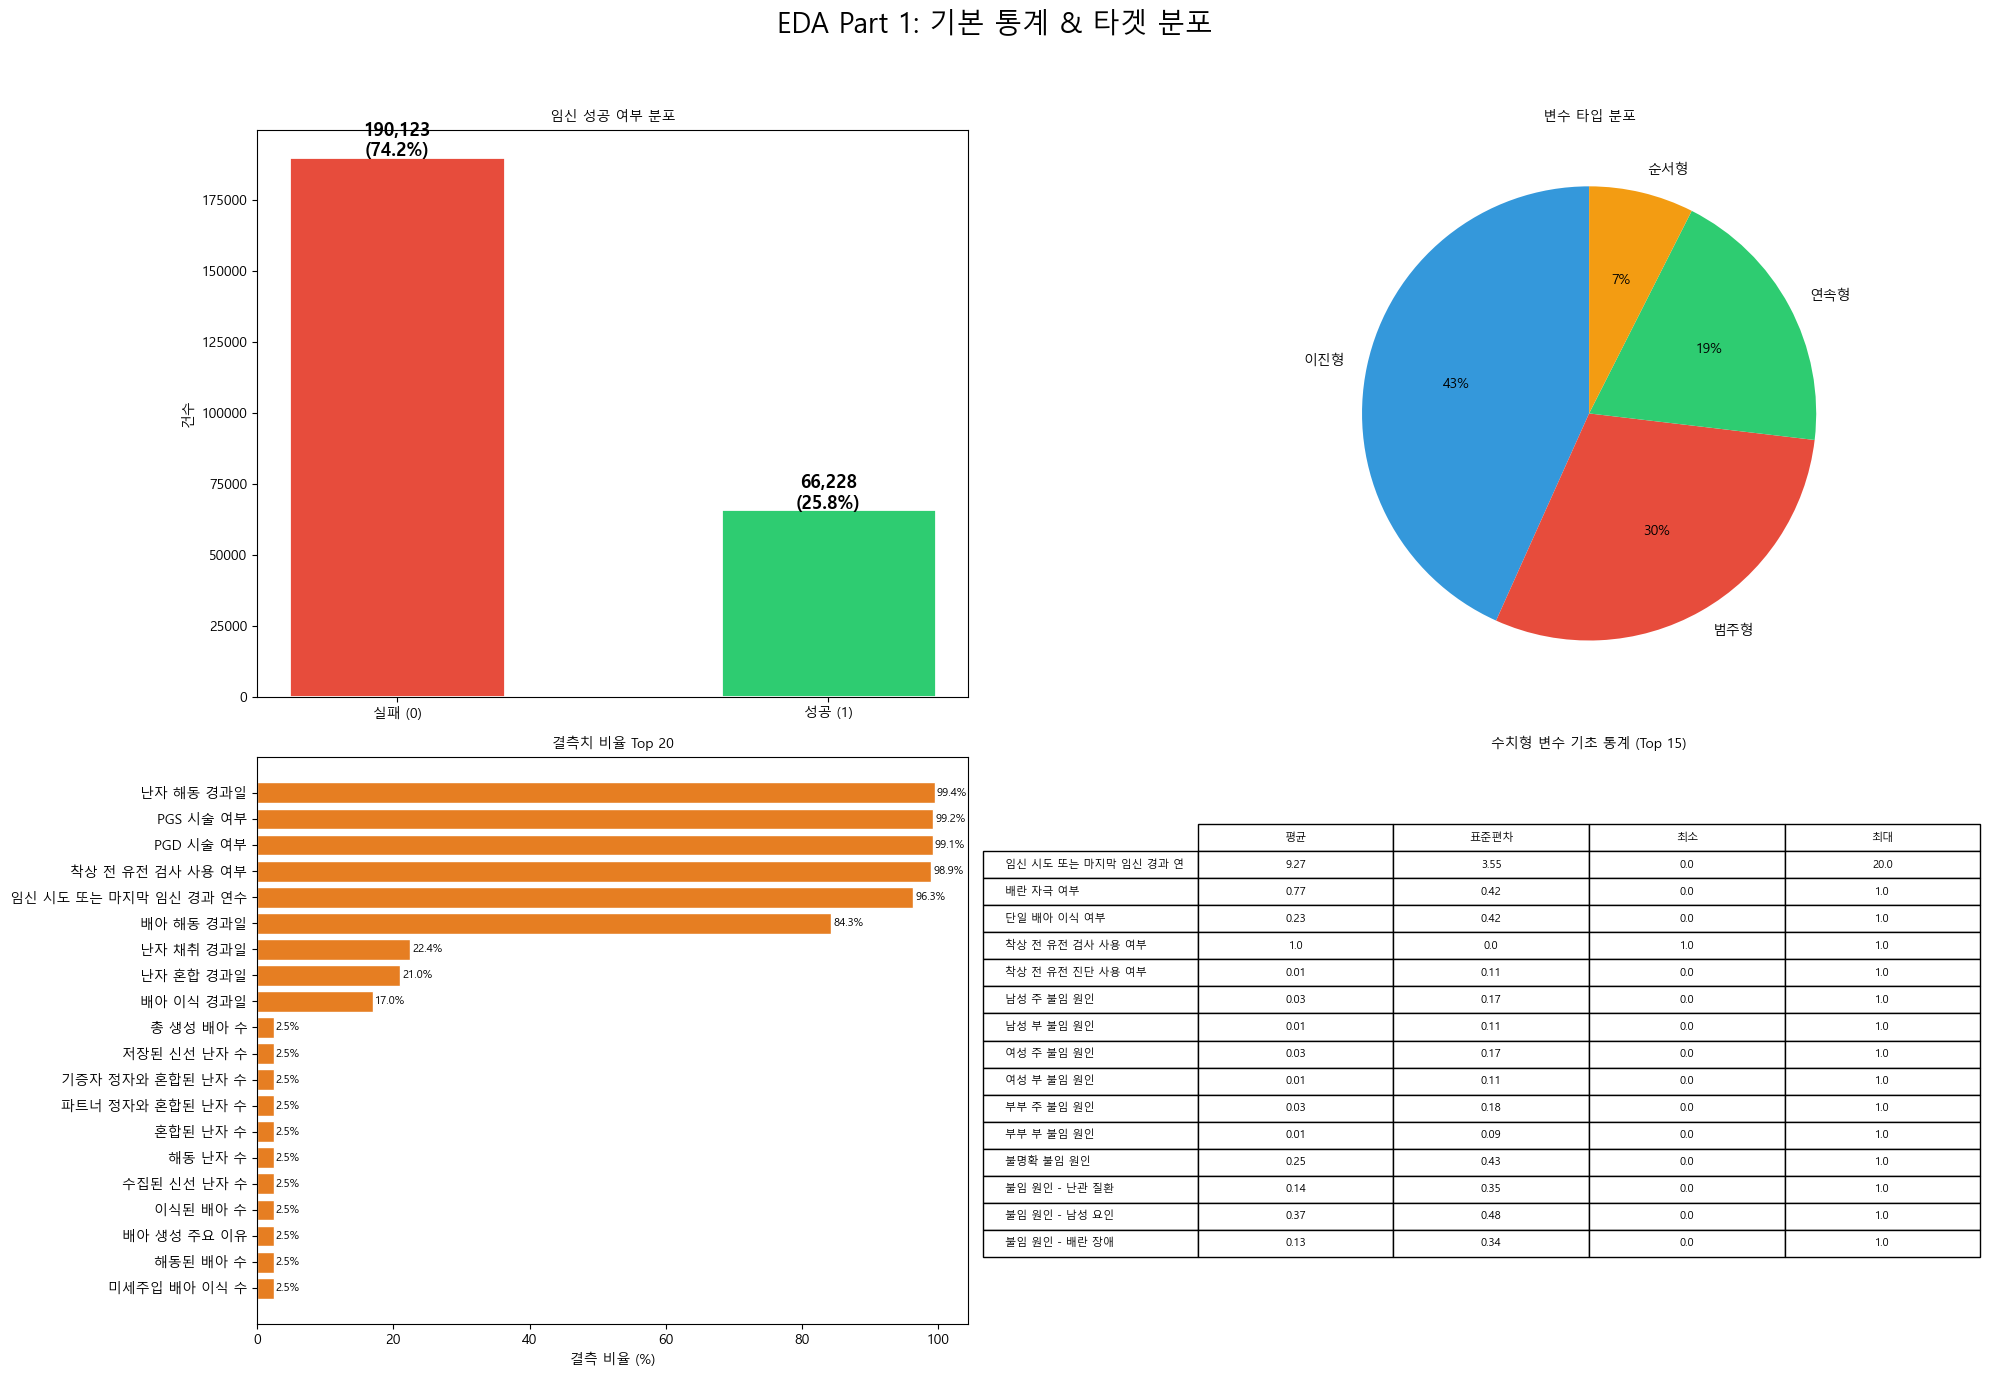

✅ Part 1 저장 완료


In [ ]:
# ============================================================
# 3) EDA Part 1 — 기본 통계 & 타겟 분포
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('EDA Part 1: 기본 통계 & 타겟 분포', fontsize=20, fontweight='bold', **fp_kw)

# 3-1) 타겟 분포
counts = train[TARGET].value_counts()
colors_target = ['#E74C3C', '#2ECC71']
bars = axes[0, 0].bar(['실패 (0)', '성공 (1)'], counts.values, color=colors_target,
                       edgecolor='white', linewidth=2, width=0.5)
for b, v in zip(bars, counts.values):
    pct = v / len(train) * 100
    axes[0, 0].text(b.get_x() + b.get_width()/2, v + 50, f'{v:,}\n({pct:.1f}%)',
                    ha='center', fontsize=13, fontweight='bold')
axes[0, 0].set_title('임신 성공 여부 분포', fontsize=14, fontweight='bold', **fp_kw)
axes[0, 0].set_ylabel('건수', **fp_kw)

# 3-2) 컬럼 타입 분포
dtype_map = {}
for col in train.columns:
    if col in ['ID', TARGET]:
        continue
    nunique = train[col].nunique()
    if train[col].dtype == 'object':
        dtype_map[col] = '범주형'
    elif set(train[col].dropna().unique()).issubset({0, 1, 0.0, 1.0}):
        dtype_map[col] = '이진형'
    elif nunique <= 10:
        dtype_map[col] = '순서형'
    else:
        dtype_map[col] = '연속형'

type_counts = pd.Series(dtype_map).value_counts()
colors_type = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12']
axes[0, 1].pie(type_counts.values, labels=type_counts.index, colors=colors_type,
               autopct='%1.0f%%', startangle=90, textprops={'fontsize': 12, **fp_kw})
axes[0, 1].set_title('변수 타입 분포', fontsize=14, fontweight='bold', **fp_kw)

# 3-3) 결측치 Top 20
missing = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
missing_top = missing[missing > 0].head(20)
bars = axes[1, 0].barh(range(len(missing_top)), missing_top.values, color='#E67E22', edgecolor='white')
axes[1, 0].set_yticks(range(len(missing_top)))
axes[1, 0].set_yticklabels(missing_top.index, fontsize=8, **fp_kw)
axes[1, 0].set_xlabel('결측 비율 (%)', **fp_kw)
axes[1, 0].set_title('결측치 비율 Top 20', fontsize=14, fontweight='bold', **fp_kw)
axes[1, 0].invert_yaxis()
for b, v in zip(bars, missing_top.values):
    axes[1, 0].text(v + 0.3, b.get_y() + b.get_height()/2, f'{v:.1f}%',
                    va='center', fontsize=8)

# 3-4) 수치형 변수 기초 통계
# num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
# if TARGET in num_cols:
#     num_cols.remove(TARGET)
# desc = train[num_cols].describe().T[['mean', 'std', 'min', 'max']].head(15)
# axes[1, 1].axis('off')
# table = axes[1, 1].table(
#     cellText=desc.round(2).values,
#     rowLabels=[c[:20] for c in desc.index],
#     colLabels=['평균', '표준편차', '최소', '최대'],
#     loc='center', cellLoc='center'
# )
# table.auto_set_font_size(False)
# table.set_fontsize(8)
# table.scale(1.1, 1.4)
# axes[1, 1].set_title('수치형 변수 기초 통계 (Top 15)', fontsize=14, fontweight='bold', **fp_kw)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('eda_part1_basic.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Part 1 저장 완료")


## EDA Part 2 — 나이 & 시술 유형별 분석

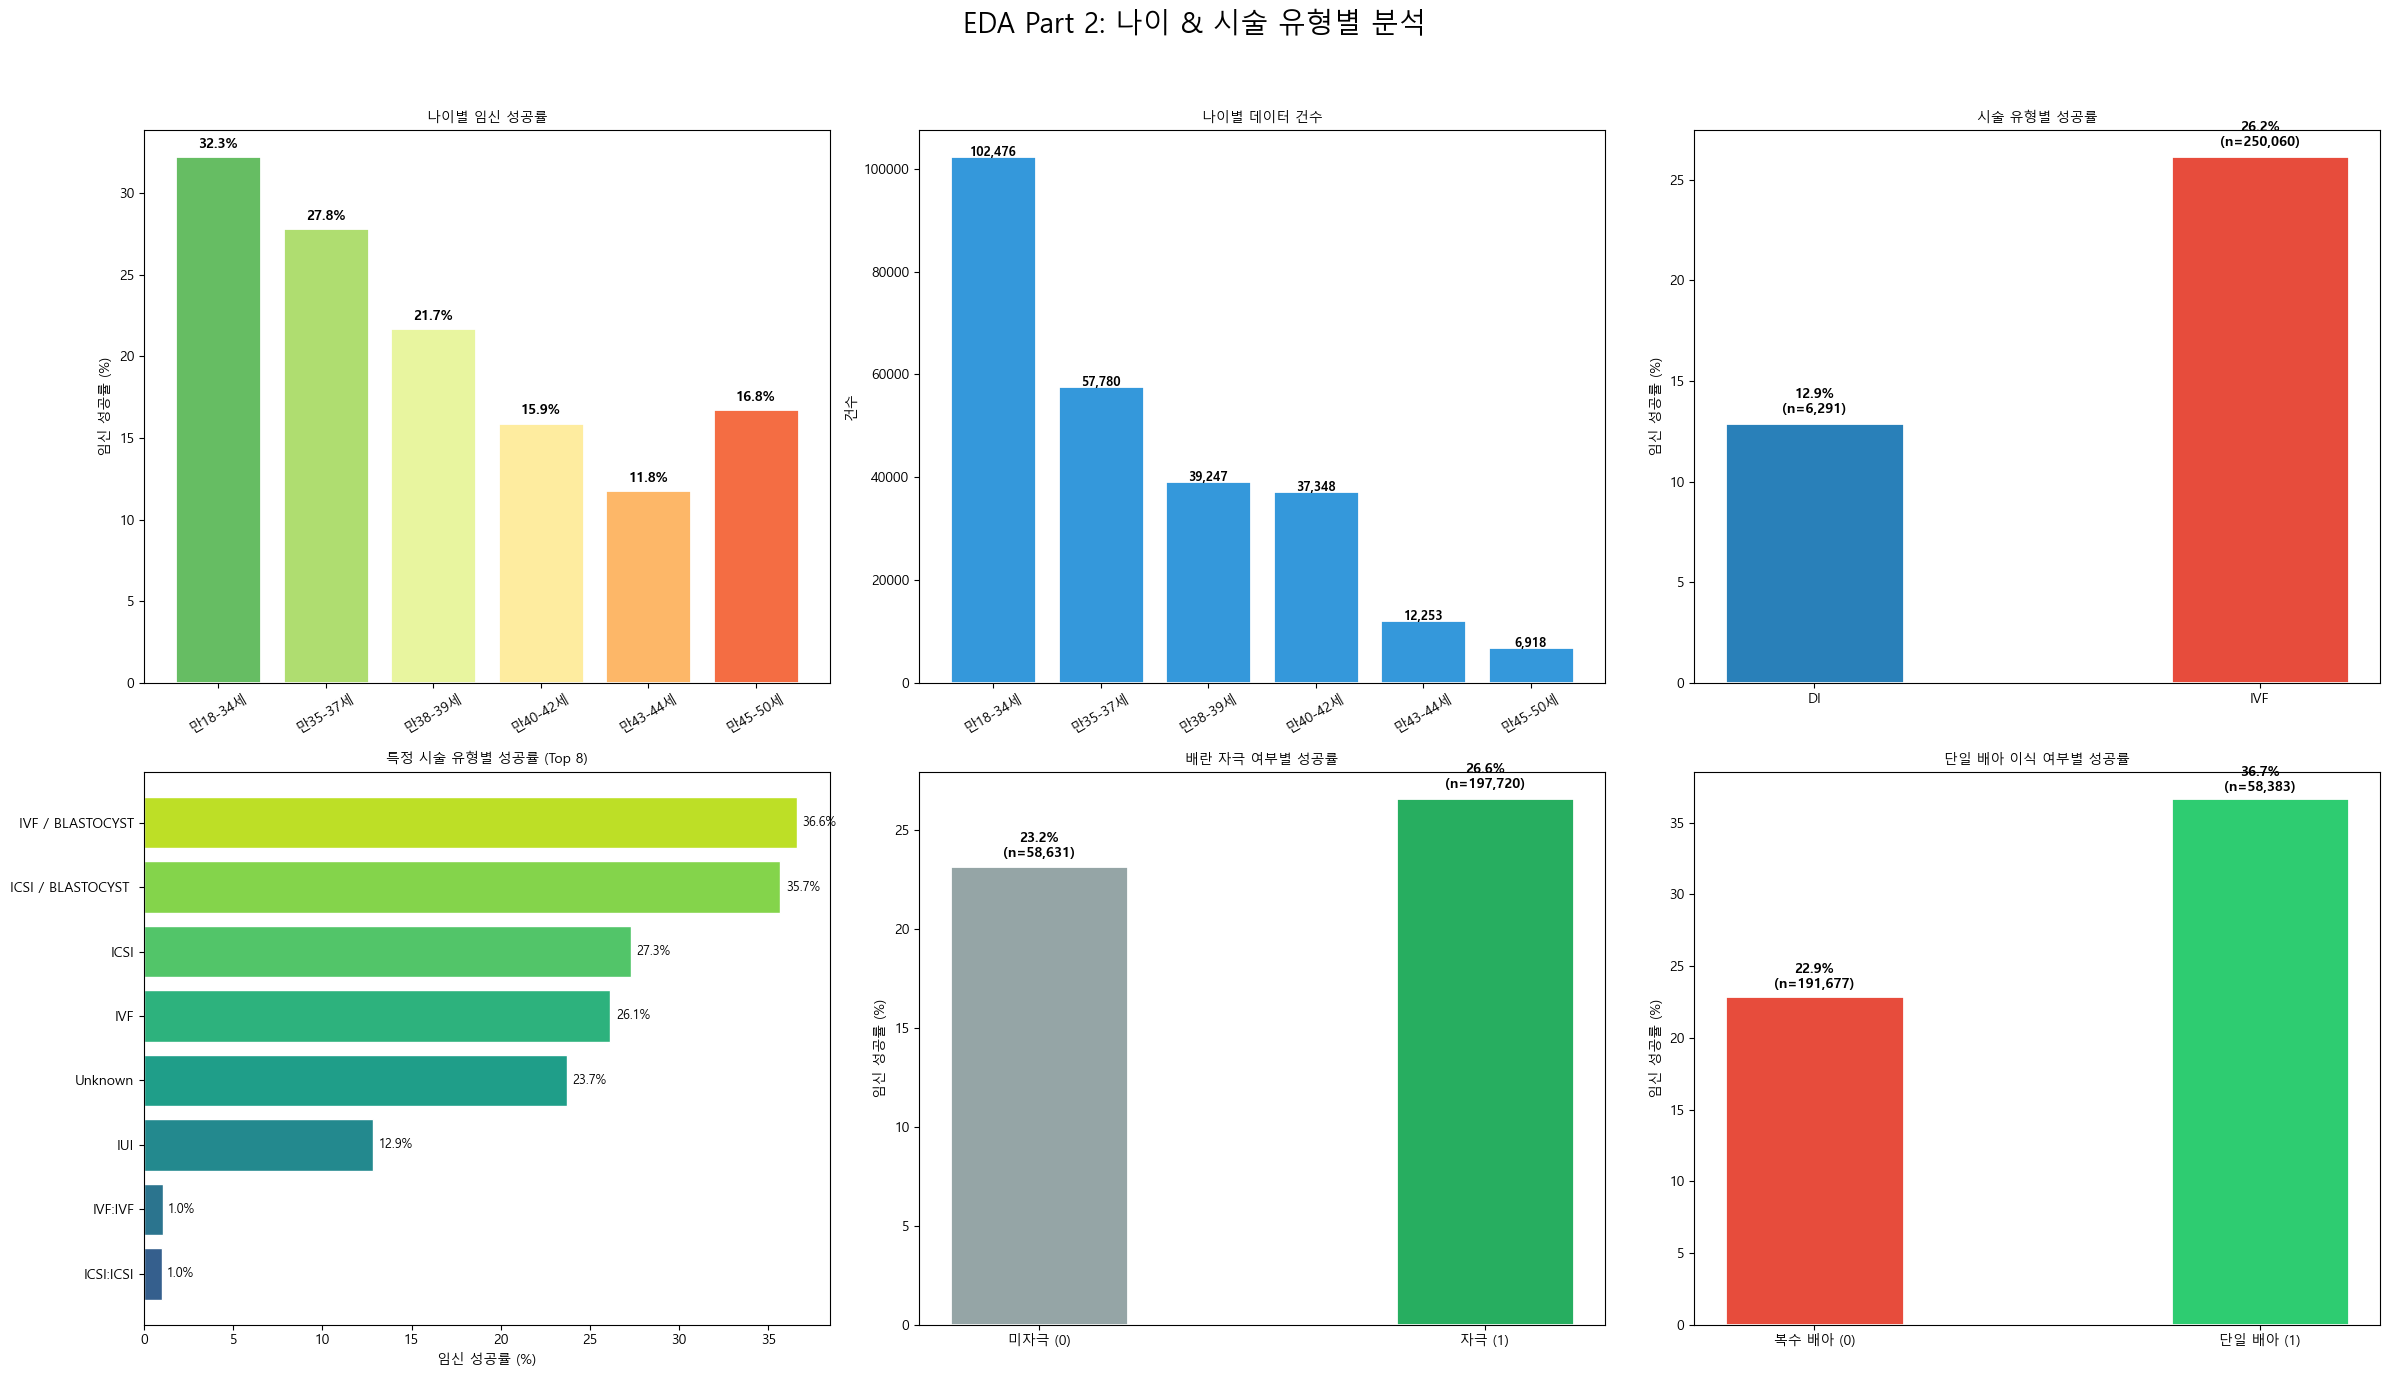

✅ Part 2 저장 완료


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle('EDA Part 2: 나이 & 시술 유형별 분석', fontsize=20, fontweight='bold', **fp_kw)

# 4-1) 나이별 임신 성공률
age_col = '시술 당시 나이'
if age_col in train.columns:
    age_order = ['만18-34세', '만35-37세', '만38-39세', '만40-42세', '만43-44세', '만45-50세']
    age_exist = [a for a in age_order if a in train[age_col].values]
    age_sr = train.groupby(age_col)[TARGET].mean().reindex(age_exist)
    
    colors_age = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(age_sr)))
    bars = axes[0, 0].bar(range(len(age_sr)), age_sr.values * 100, color=colors_age,
                           edgecolor='white', linewidth=2)
    axes[0, 0].set_xticks(range(len(age_sr)))
    axes[0, 0].set_xticklabels(age_sr.index, rotation=30, fontsize=9, **fp_kw)
    axes[0, 0].set_ylabel('임신 성공률 (%)', **fp_kw)
    axes[0, 0].set_title('나이별 임신 성공률', fontsize=14, fontweight='bold', **fp_kw)
    for b, v in zip(bars, age_sr.values):
        axes[0, 0].text(b.get_x() + b.get_width()/2, v*100 + 0.5, f'{v*100:.1f}%',
                        ha='center', fontsize=10, fontweight='bold')

# 4-2) 나이별 케이스 수
if age_col in train.columns:
    age_counts = train[age_col].value_counts().reindex(age_exist)
    axes[0, 1].bar(range(len(age_counts)), age_counts.values, color='#3498DB',
                    edgecolor='white', linewidth=2)
    axes[0, 1].set_xticks(range(len(age_counts)))
    axes[0, 1].set_xticklabels(age_counts.index, rotation=30, fontsize=9, **fp_kw)
    axes[0, 1].set_ylabel('건수', **fp_kw)
    axes[0, 1].set_title('나이별 데이터 건수', fontsize=14, fontweight='bold', **fp_kw)
    for i, v in enumerate(age_counts.values):
        axes[0, 1].text(i, v + 20, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

# 4-3) 시술 유형별 성공률
proc_col = '시술 유형'
if proc_col in train.columns:
    proc_sr = train.groupby(proc_col)[TARGET].agg(['mean', 'count'])
    proc_colors = ['#2980B9', '#E74C3C']
    bars = axes[0, 2].bar(proc_sr.index, proc_sr['mean'] * 100, color=proc_colors[:len(proc_sr)],
                           edgecolor='white', linewidth=2, width=0.4)
    axes[0, 2].set_ylabel('임신 성공률 (%)', **fp_kw)
    axes[0, 2].set_title('시술 유형별 성공률', fontsize=14, fontweight='bold', **fp_kw)
    for b, (idx, row) in zip(bars, proc_sr.iterrows()):
        axes[0, 2].text(b.get_x() + b.get_width()/2, row['mean']*100 + 0.5,
                        f"{row['mean']*100:.1f}%\n(n={int(row['count']):,})",
                        ha='center', fontsize=10, fontweight='bold')

# 4-4) 특정 시술 유형별 성공률
spec_col = '특정 시술 유형'
if spec_col in train.columns:
    top_specs = train[spec_col].value_counts().head(8).index
    spec_data = train[train[spec_col].isin(top_specs)]
    spec_sr = spec_data.groupby(spec_col)[TARGET].mean().sort_values(ascending=True)
    
    axes[1, 0].barh(range(len(spec_sr)), spec_sr.values * 100,
                     color=plt.cm.viridis(np.linspace(0.3, 0.9, len(spec_sr))),
                     edgecolor='white')
    axes[1, 0].set_yticks(range(len(spec_sr)))
    axes[1, 0].set_yticklabels(spec_sr.index, fontsize=9, **fp_kw)
    axes[1, 0].set_xlabel('임신 성공률 (%)', **fp_kw)
    axes[1, 0].set_title('특정 시술 유형별 성공률 (Top 8)', fontsize=14, fontweight='bold', **fp_kw)
    for i, v in enumerate(spec_sr.values):
        axes[1, 0].text(v*100 + 0.3, i, f'{v*100:.1f}%', va='center', fontsize=9)

# 4-5) 배란 자극 여부별 성공률
ovul_col = '배란 자극 여부'
if ovul_col in train.columns:
    ovul_data = train.groupby(ovul_col)[TARGET].agg(['mean', 'count']).dropna()
    ovul_labels = ['미자극 (0)', '자극 (1)']
    axes[1, 1].bar(ovul_labels[:len(ovul_data)], ovul_data['mean'].values * 100,
                    color=['#95A5A6', '#27AE60'], edgecolor='white', linewidth=2, width=0.4)
    axes[1, 1].set_ylabel('임신 성공률 (%)', **fp_kw)
    axes[1, 1].set_title('배란 자극 여부별 성공률', fontsize=14, fontweight='bold', **fp_kw)
    for i, (_, row) in enumerate(ovul_data.iterrows()):
        axes[1, 1].text(i, row['mean']*100 + 0.5,
                        f"{row['mean']*100:.1f}%\n(n={int(row['count']):,})",
                        ha='center', fontsize=10, fontweight='bold')

# 4-6) 단일 배아 이식 여부별 성공률
single_col = '단일 배아 이식 여부'
if single_col in train.columns:
    single_data = train.groupby(single_col)[TARGET].agg(['mean', 'count']).dropna()
    s_labels = ['복수 배아 (0)', '단일 배아 (1)']
    axes[1, 2].bar(s_labels[:len(single_data)], single_data['mean'].values * 100,
                    color=['#E74C3C', '#2ECC71'], edgecolor='white', linewidth=2, width=0.4)
    axes[1, 2].set_ylabel('임신 성공률 (%)', **fp_kw)
    axes[1, 2].set_title('단일 배아 이식 여부별 성공률', fontsize=14, fontweight='bold', **fp_kw)
    for i, (_, row) in enumerate(single_data.iterrows()):
        axes[1, 2].text(i, row['mean']*100 + 0.5,
                        f"{row['mean']*100:.1f}%\n(n={int(row['count']):,})",
                        ha='center', fontsize=10, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('eda_part2_age_procedure.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Part 2 저장 완료")

## EDA Part 3 — 배아/난자 수치 분석

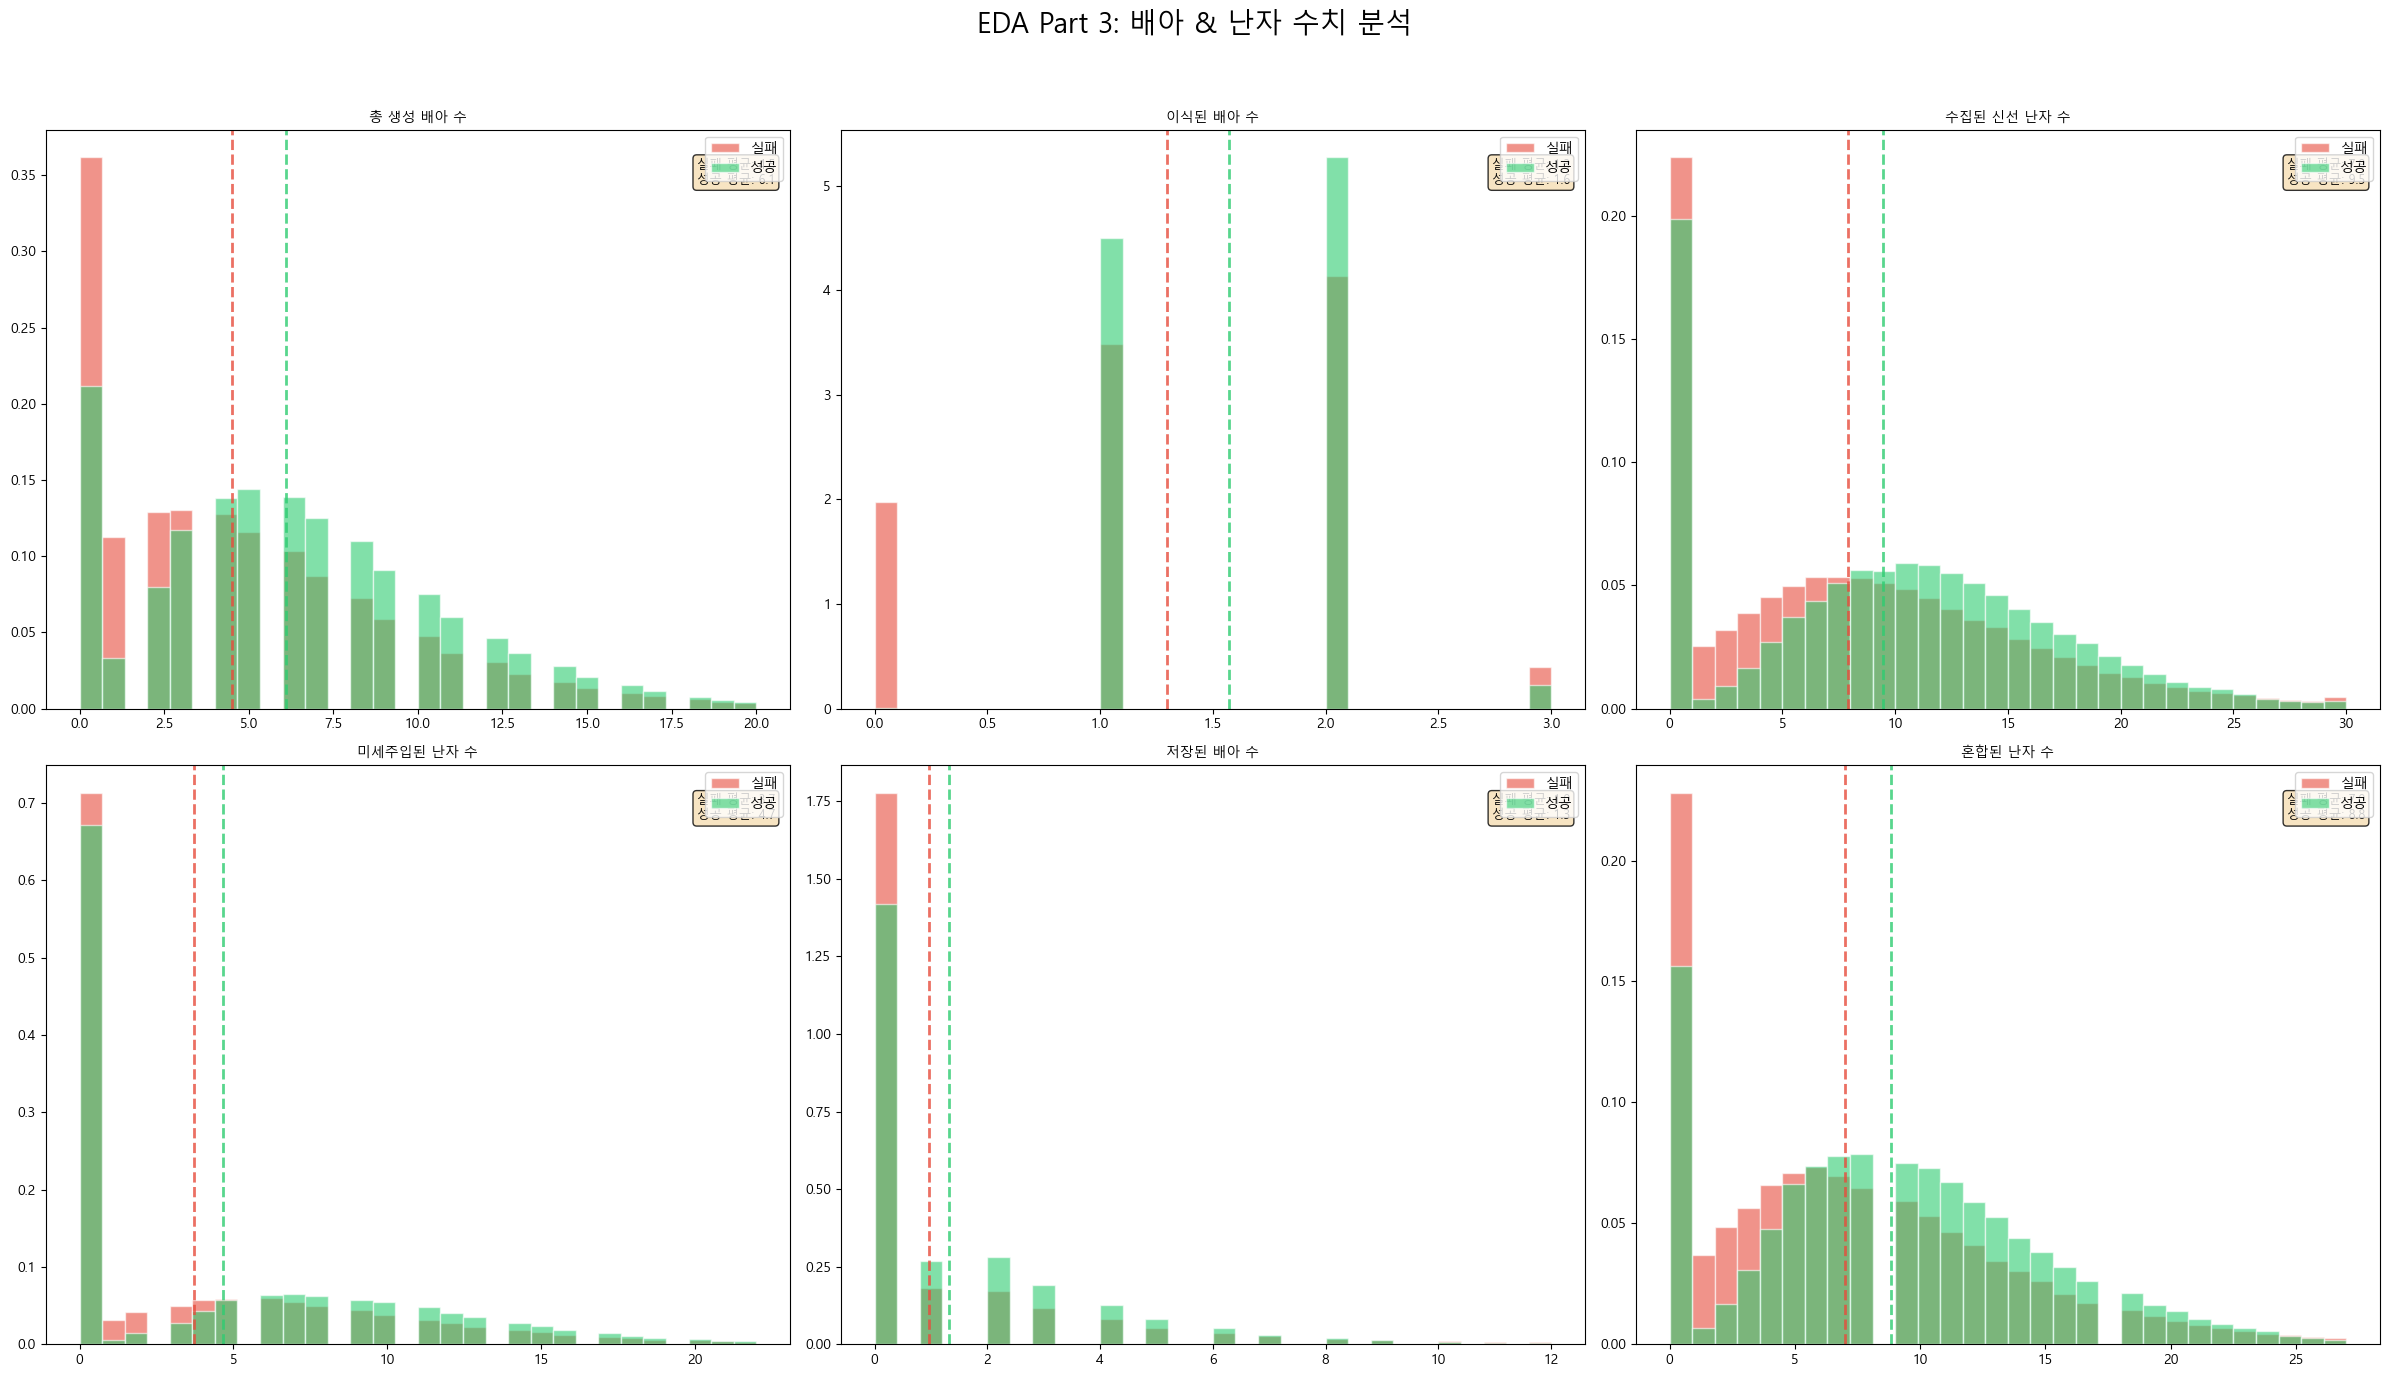

✅ Part 3 저장 완료


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle('EDA Part 3: 배아 & 난자 수치 분석', fontsize=20, fontweight='bold', **fp_kw)

embryo_cols = ['총 생성 배아 수', '이식된 배아 수', '수집된 신선 난자 수',
               '미세주입된 난자 수', '저장된 배아 수', '혼합된 난자 수']

for i, col in enumerate(embryo_cols):
    row, c = divmod(i, 3)
    ax = axes[row, c]
    
    if col not in train.columns:
        ax.set_visible(False)
        continue
    
    data_0 = train[train[TARGET] == 0][col].dropna()
    data_1 = train[train[TARGET] == 1][col].dropna()
    
    # 이상치 제거 (99% percentile)
    upper = train[col].quantile(0.99)
    data_0 = data_0[data_0 <= upper]
    data_1 = data_1[data_1 <= upper]
    
    ax.hist(data_0, bins=30, alpha=0.6, color='#E74C3C', label='실패', density=True, edgecolor='white')
    ax.hist(data_1, bins=30, alpha=0.6, color='#2ECC71', label='성공', density=True, edgecolor='white')
    ax.set_title(col, fontsize=12, fontweight='bold', **fp_kw)
    ax.legend(prop=fp if fp else {})
    
    # 평균선
    ax.axvline(data_0.mean(), color='#E74C3C', linestyle='--', linewidth=2, alpha=0.8)
    ax.axvline(data_1.mean(), color='#2ECC71', linestyle='--', linewidth=2, alpha=0.8)
    
    ax.text(0.98, 0.95, f'실패 평균: {data_0.mean():.1f}\n성공 평균: {data_1.mean():.1f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), **fp_kw)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('eda_part3_embryo.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Part 3 저장 완료")

## EDA Part 4 — 불임 원인 분석

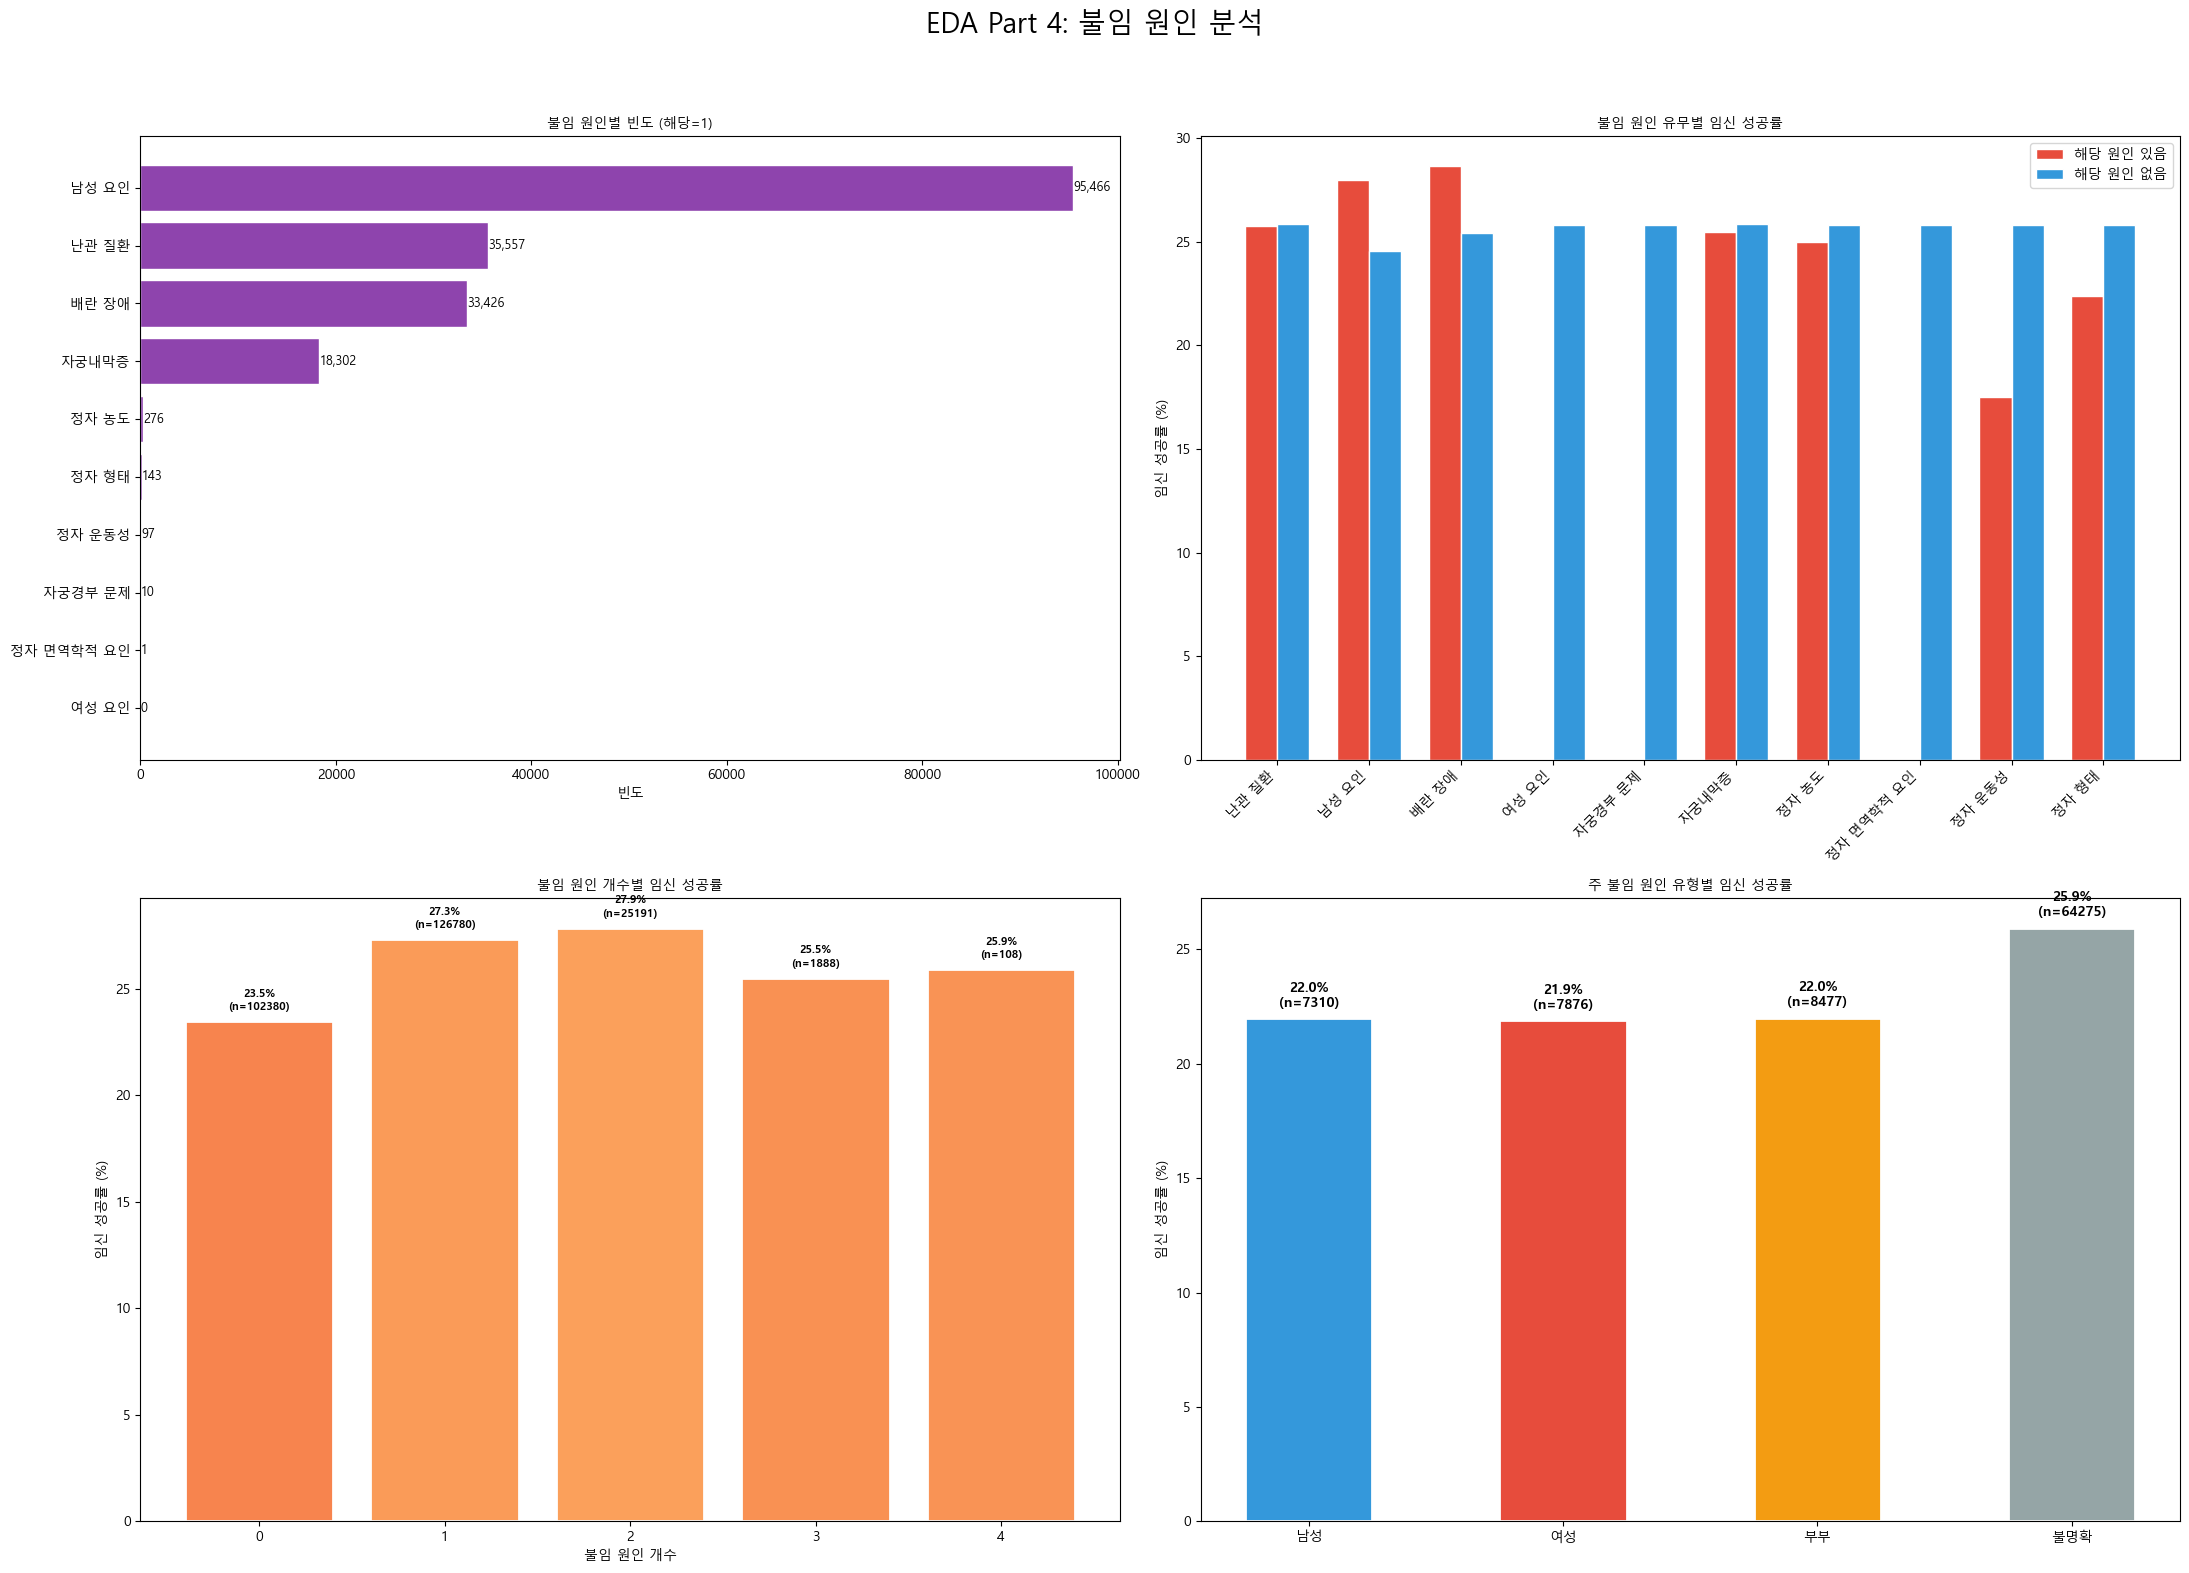

✅ Part 4 저장 완료


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(22, 16))
fig.suptitle('EDA Part 4: 불임 원인 분석', fontsize=20, fontweight='bold', **fp_kw)

infertility_cols = [
    '불임 원인 - 난관 질환', '불임 원인 - 남성 요인', '불임 원인 - 배란 장애',
    '불임 원인 - 여성 요인', '불임 원인 - 자궁경부 문제', '불임 원인 - 자궁내막증',
    '불임 원인 - 정자 농도', '불임 원인 - 정자 면역학적 요인',
    '불임 원인 - 정자 운동성', '불임 원인 - 정자 형태'
]
inf_exist = [c for c in infertility_cols if c in train.columns]

# 6-1) 불임 원인 빈도
if inf_exist:
    freq = train[inf_exist].sum().sort_values(ascending=True)
    short_names = [c.replace('불임 원인 - ', '') for c in freq.index]
    
    axes[0, 0].barh(range(len(freq)), freq.values, color='#8E44AD', edgecolor='white')
    axes[0, 0].set_yticks(range(len(freq)))
    axes[0, 0].set_yticklabels(short_names, fontsize=10, **fp_kw)
    axes[0, 0].set_xlabel('빈도', **fp_kw)
    axes[0, 0].set_title('불임 원인별 빈도 (해당=1)', fontsize=14, fontweight='bold', **fp_kw)
    for i, v in enumerate(freq.values):
        axes[0, 0].text(v + 10, i, f'{v:,}', va='center', fontsize=9)

# 6-2) 불임 원인별 임신 성공률
if inf_exist:
    success_rates = {}
    for col in inf_exist:
        has = train[train[col] == 1][TARGET].mean()
        not_has = train[train[col] == 0][TARGET].mean()
        success_rates[col.replace('불임 원인 - ', '')] = {'있음': has, '없음': not_has}
    
    sr_df = pd.DataFrame(success_rates).T
    x_pos = np.arange(len(sr_df))
    w = 0.35
    
    axes[0, 1].bar(x_pos - w/2, sr_df['있음'] * 100, w, label='해당 원인 있음',
                    color='#E74C3C', edgecolor='white')
    axes[0, 1].bar(x_pos + w/2, sr_df['없음'] * 100, w, label='해당 원인 없음',
                    color='#3498DB', edgecolor='white')
    axes[0, 1].set_xticks(x_pos)
    axes[0, 1].set_xticklabels(sr_df.index, rotation=45, ha='right', fontsize=9, **fp_kw)
    axes[0, 1].set_ylabel('임신 성공률 (%)', **fp_kw)
    axes[0, 1].set_title('불임 원인 유무별 임신 성공률', fontsize=14, fontweight='bold', **fp_kw)
    axes[0, 1].legend(prop=fp if fp else {})

# 6-3) 불임 원인 개수별 성공률
if inf_exist:
    train['불임원인_총합'] = train[inf_exist].sum(axis=1)
    cause_count = train.groupby('불임원인_총합')[TARGET].agg(['mean', 'count'])
    cause_count = cause_count[cause_count['count'] >= 10]
    
    ax2 = axes[1, 0]
    color_map = plt.cm.RdYlGn(cause_count['mean'].values)
    bars = ax2.bar(cause_count.index.astype(str), cause_count['mean'] * 100,
                    color=color_map, edgecolor='white', linewidth=2)
    ax2.set_xlabel('불임 원인 개수', **fp_kw)
    ax2.set_ylabel('임신 성공률 (%)', **fp_kw)
    ax2.set_title('불임 원인 개수별 임신 성공률', fontsize=14, fontweight='bold', **fp_kw)
    for b, (idx, row) in zip(bars, cause_count.iterrows()):
        ax2.text(b.get_x() + b.get_width()/2, row['mean']*100 + 0.5,
                 f"{row['mean']*100:.1f}%\n(n={int(row['count'])})",
                 ha='center', fontsize=8, fontweight='bold')

# 6-4) 주 불임 원인 유형별 성공률
main_cause_cols = ['남성 주 불임 원인', '여성 주 불임 원인', '부부 주 불임 원인', '불명확 불임 원인']
mc_exist = [c for c in main_cause_cols if c in train.columns]

if mc_exist:
    mc_rates = {}
    for col in mc_exist:
        rate = train[train[col] == 1][TARGET].mean()
        cnt = train[col].sum()
        mc_rates[col.replace(' 주 불임 원인', '').replace(' 불임 원인', '')] = {
            'rate': rate, 'count': cnt
        }
    
    mc_df = pd.DataFrame(mc_rates).T
    bars = axes[1, 1].bar(mc_df.index, mc_df['rate'] * 100,
                           color=['#3498DB', '#E74C3C', '#F39C12', '#95A5A6'],
                           edgecolor='white', linewidth=2, width=0.5)
    axes[1, 1].set_ylabel('임신 성공률 (%)', **fp_kw)
    axes[1, 1].set_title('주 불임 원인 유형별 임신 성공률', fontsize=14, fontweight='bold', **fp_kw)
    for b, (idx, row) in zip(bars, mc_df.iterrows()):
        axes[1, 1].text(b.get_x() + b.get_width()/2, row['rate']*100 + 0.5,
                        f"{row['rate']*100:.1f}%\n(n={int(row['count'])})",
                        ha='center', fontsize=10, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('eda_part4_infertility.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Part 4 저장 완료")


## EDA Part 5 — 시술 이력 & 상관관계

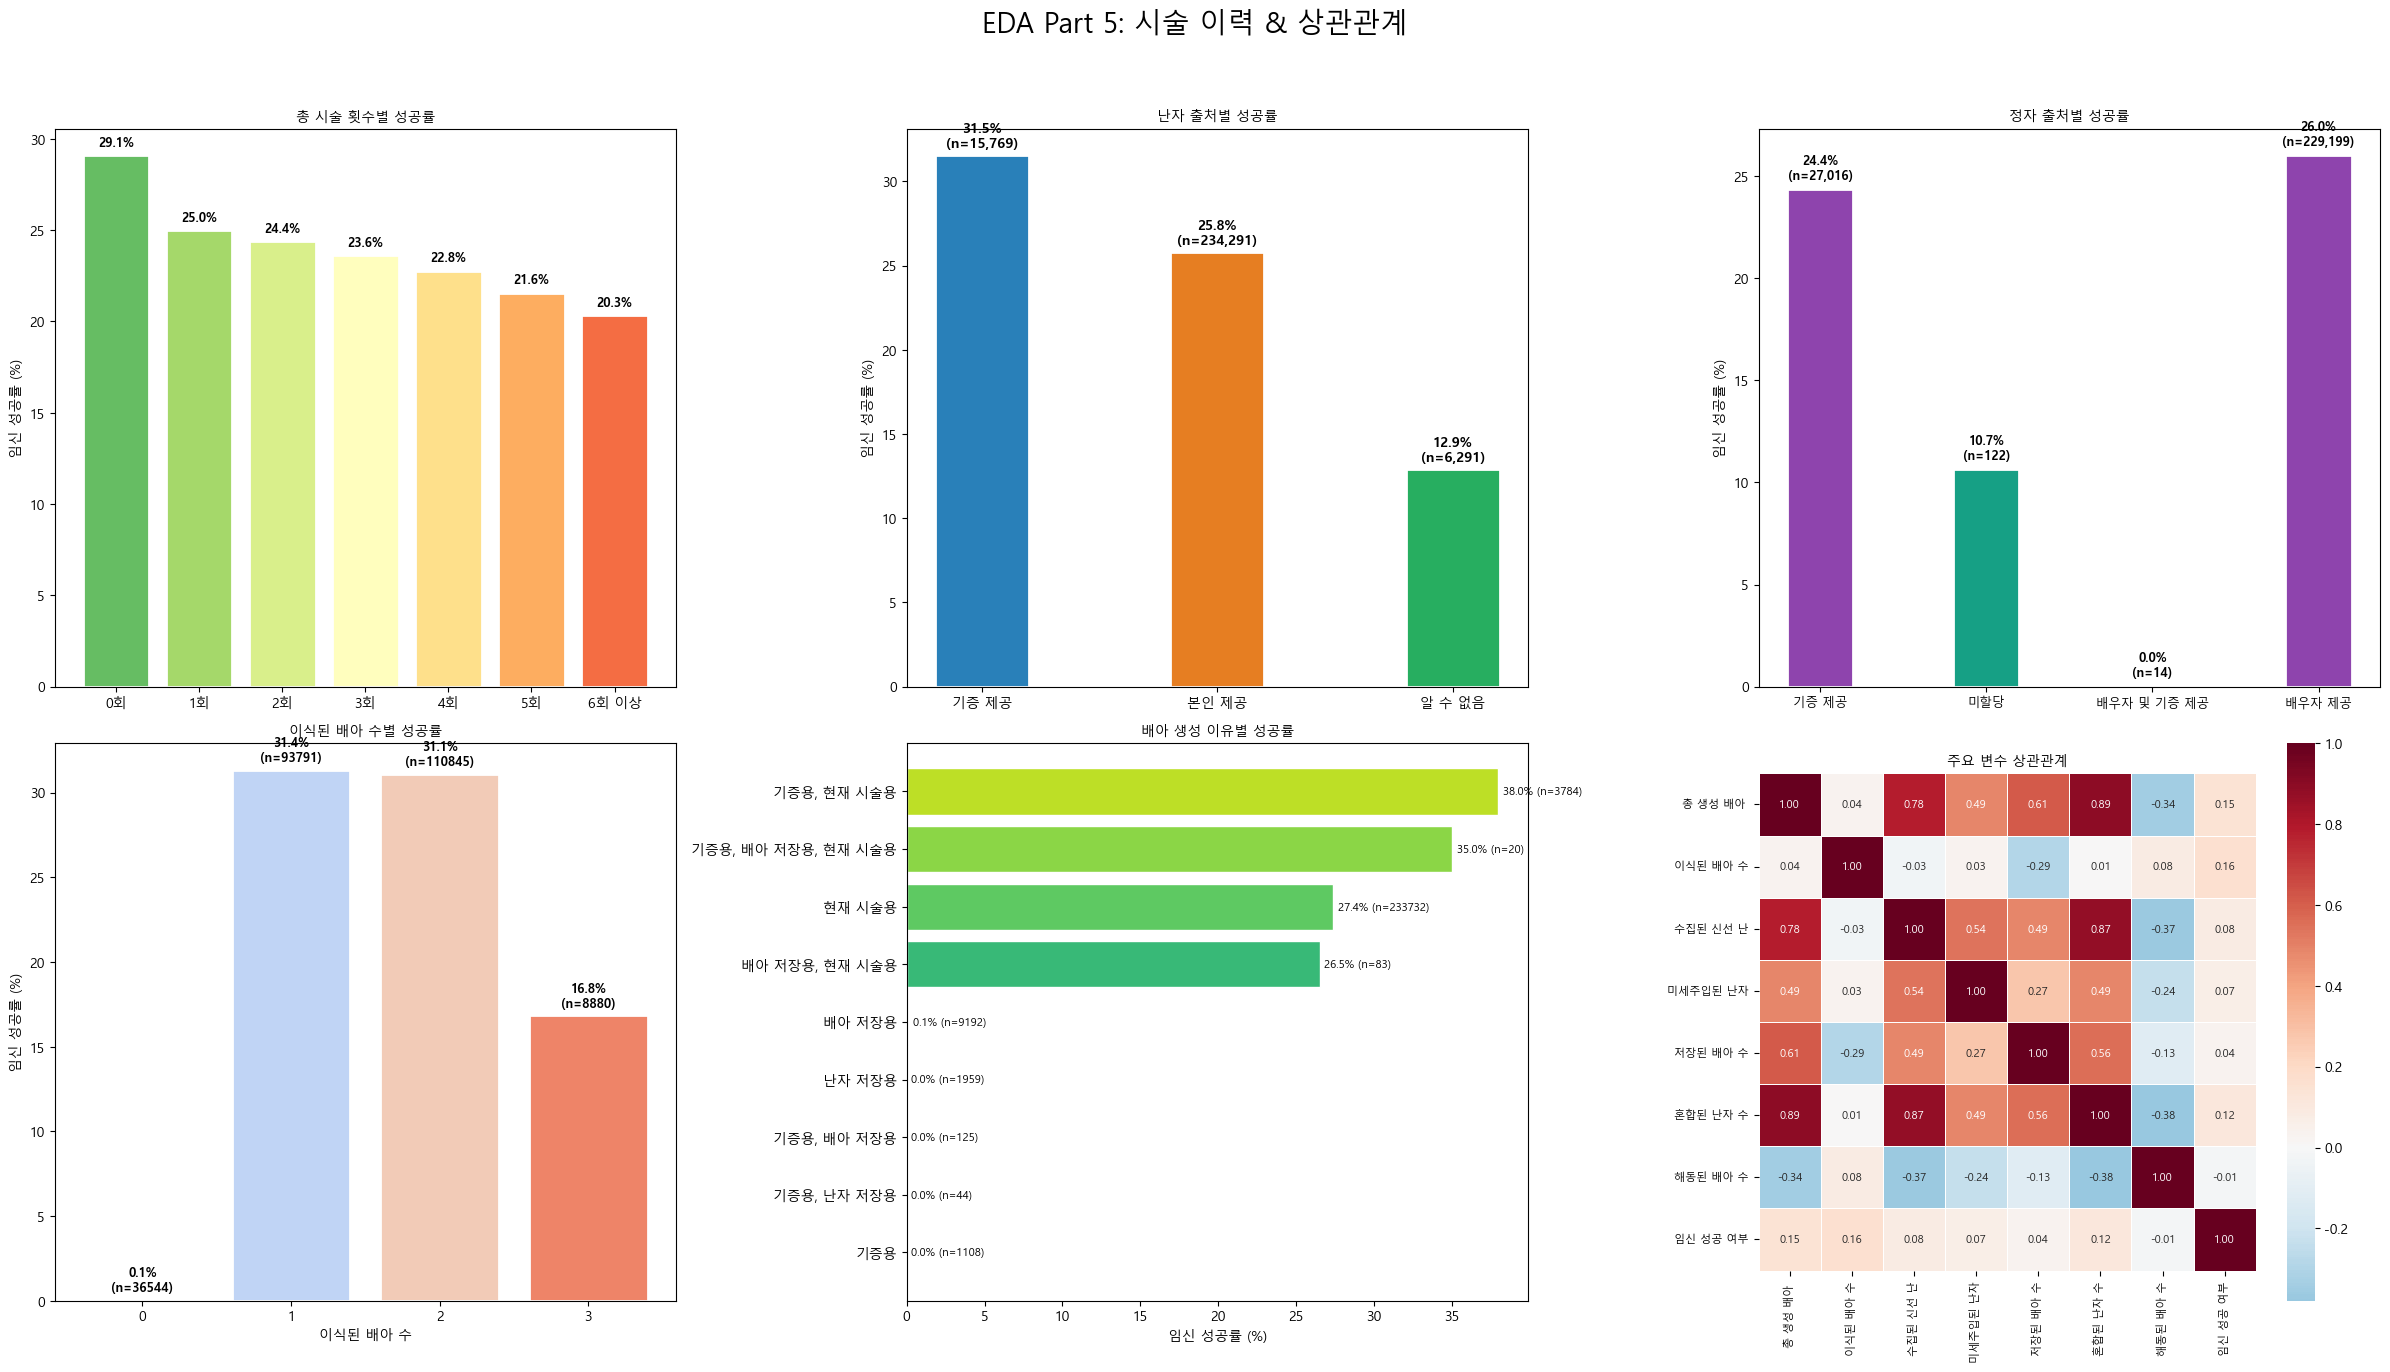

✅ Part 5 저장 완료


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle('EDA Part 5: 시술 이력 & 상관관계', fontsize=20, fontweight='bold', **fp_kw)

# 7-1) 총 시술 횟수별 성공률
count_col = '총 시술 횟수'
if count_col in train.columns:
    count_order = ['0회', '1회', '2회', '3회', '4회', '5회', '6회 이상']
    count_exist = [c for c in count_order if c in train[count_col].values]
    cnt_sr = train.groupby(count_col)[TARGET].agg(['mean', 'count']).reindex(count_exist)
    cnt_sr = cnt_sr.dropna()
    
    color_map = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(cnt_sr)))
    bars = axes[0, 0].bar(range(len(cnt_sr)), cnt_sr['mean'] * 100, color=color_map,
                           edgecolor='white', linewidth=2)
    axes[0, 0].set_xticks(range(len(cnt_sr)))
    axes[0, 0].set_xticklabels(cnt_sr.index, fontsize=9, **fp_kw)
    axes[0, 0].set_ylabel('임신 성공률 (%)', **fp_kw)
    axes[0, 0].set_title('총 시술 횟수별 성공률', fontsize=14, fontweight='bold', **fp_kw)
    for b, (idx, row) in zip(bars, cnt_sr.iterrows()):
        axes[0, 0].text(b.get_x() + b.get_width()/2, row['mean']*100 + 0.5,
                        f"{row['mean']*100:.1f}%", ha='center', fontsize=9, fontweight='bold')

# 7-2) 난자 출처별 성공률
egg_col = '난자 출처'
if egg_col in train.columns:
    egg_sr = train.groupby(egg_col)[TARGET].agg(['mean', 'count'])
    bars = axes[0, 1].bar(egg_sr.index, egg_sr['mean'] * 100,
                           color=['#2980B9', '#E67E22', '#27AE60'][:len(egg_sr)],
                           edgecolor='white', linewidth=2, width=0.4)
    axes[0, 1].set_ylabel('임신 성공률 (%)', **fp_kw)
    axes[0, 1].set_title('난자 출처별 성공률', fontsize=14, fontweight='bold', **fp_kw)
    for b, (idx, row) in zip(bars, egg_sr.iterrows()):
        axes[0, 1].text(b.get_x() + b.get_width()/2, row['mean']*100 + 0.5,
                        f"{row['mean']*100:.1f}%\n(n={int(row['count']):,})",
                        ha='center', fontsize=10, fontweight='bold')

# 7-3) 정자 출처별 성공률
sperm_col = '정자 출처'
if sperm_col in train.columns:
    sp_sr = train.groupby(sperm_col)[TARGET].agg(['mean', 'count'])
    bars = axes[0, 2].bar(sp_sr.index, sp_sr['mean'] * 100,
                           color=['#8E44AD', '#16A085', '#D35400'][:len(sp_sr)],
                           edgecolor='white', linewidth=2, width=0.4)
    axes[0, 2].set_ylabel('임신 성공률 (%)', **fp_kw)
    axes[0, 2].set_title('정자 출처별 성공률', fontsize=14, fontweight='bold', **fp_kw)
    axes[0, 2].tick_params(axis='x', labelsize=9)
    for b, (idx, row) in zip(bars, sp_sr.iterrows()):
        axes[0, 2].text(b.get_x() + b.get_width()/2, row['mean']*100 + 0.5,
                        f"{row['mean']*100:.1f}%\n(n={int(row['count']):,})",
                        ha='center', fontsize=9, fontweight='bold')

# 7-4) 이식된 배아 수별 성공률
emb_col = '이식된 배아 수'
if emb_col in train.columns:
    emb_data = train[train[emb_col].notna()].copy()
    emb_data[emb_col] = emb_data[emb_col].astype(int)
    top_emb = emb_data[emb_col].value_counts().head(6).index.sort_values()
    emb_filtered = emb_data[emb_data[emb_col].isin(top_emb)]
    emb_sr = emb_filtered.groupby(emb_col)[TARGET].agg(['mean', 'count'])
    
    bars = axes[1, 0].bar(emb_sr.index.astype(str), emb_sr['mean'] * 100,
                           color=plt.cm.coolwarm(np.linspace(0.2, 0.8, len(emb_sr))),
                           edgecolor='white', linewidth=2)
    axes[1, 0].set_xlabel('이식된 배아 수', **fp_kw)
    axes[1, 0].set_ylabel('임신 성공률 (%)', **fp_kw)
    axes[1, 0].set_title('이식된 배아 수별 성공률', fontsize=14, fontweight='bold', **fp_kw)
    for b, (idx, row) in zip(bars, emb_sr.iterrows()):
        axes[1, 0].text(b.get_x() + b.get_width()/2, row['mean']*100 + 0.5,
                        f"{row['mean']*100:.1f}%\n(n={int(row['count'])})",
                        ha='center', fontsize=9, fontweight='bold')

# 7-5) 배아 생성 이유별 성공률
reason_col = '배아 생성 주요 이유'
if reason_col in train.columns:
    reason_sr = train.groupby(reason_col)[TARGET].agg(['mean', 'count'])
    reason_sr = reason_sr[reason_sr['count'] >= 20].sort_values('mean', ascending=True)
    
    axes[1, 1].barh(range(len(reason_sr)), reason_sr['mean'] * 100,
                     color=plt.cm.viridis(np.linspace(0.3, 0.9, len(reason_sr))),
                     edgecolor='white')
    axes[1, 1].set_yticks(range(len(reason_sr)))
    axes[1, 1].set_yticklabels(reason_sr.index, fontsize=8, **fp_kw)
    axes[1, 1].set_xlabel('임신 성공률 (%)', **fp_kw)
    axes[1, 1].set_title('배아 생성 이유별 성공률', fontsize=14, fontweight='bold', **fp_kw)
    for i, (idx, row) in enumerate(reason_sr.iterrows()):
        axes[1, 1].text(row['mean']*100 + 0.3, i,
                        f"{row['mean']*100:.1f}% (n={int(row['count'])})",
                        va='center', fontsize=8)

# 7-6) 주요 수치형 변수 상관관계 히트맵
key_num = ['총 생성 배아 수', '이식된 배아 수', '수집된 신선 난자 수',
           '미세주입된 난자 수', '저장된 배아 수', '혼합된 난자 수',
           '해동된 배아 수', TARGET]
key_exist = [c for c in key_num if c in train.columns]

if len(key_exist) > 2:
    corr = train[key_exist].corr()
    short = [c[:8] for c in corr.columns]
    
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                xticklabels=short, yticklabels=short,
                ax=axes[1, 2], linewidths=0.5, square=True,
                annot_kws={'size': 8})
    axes[1, 2].set_title('주요 변수 상관관계', fontsize=14, fontweight='bold', **fp_kw)
    axes[1, 2].tick_params(axis='both', labelsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('eda_part5_history_corr.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Part 5 저장 완료")


## EDA Part 6 — 신선 vs 동결 & 기증 분석

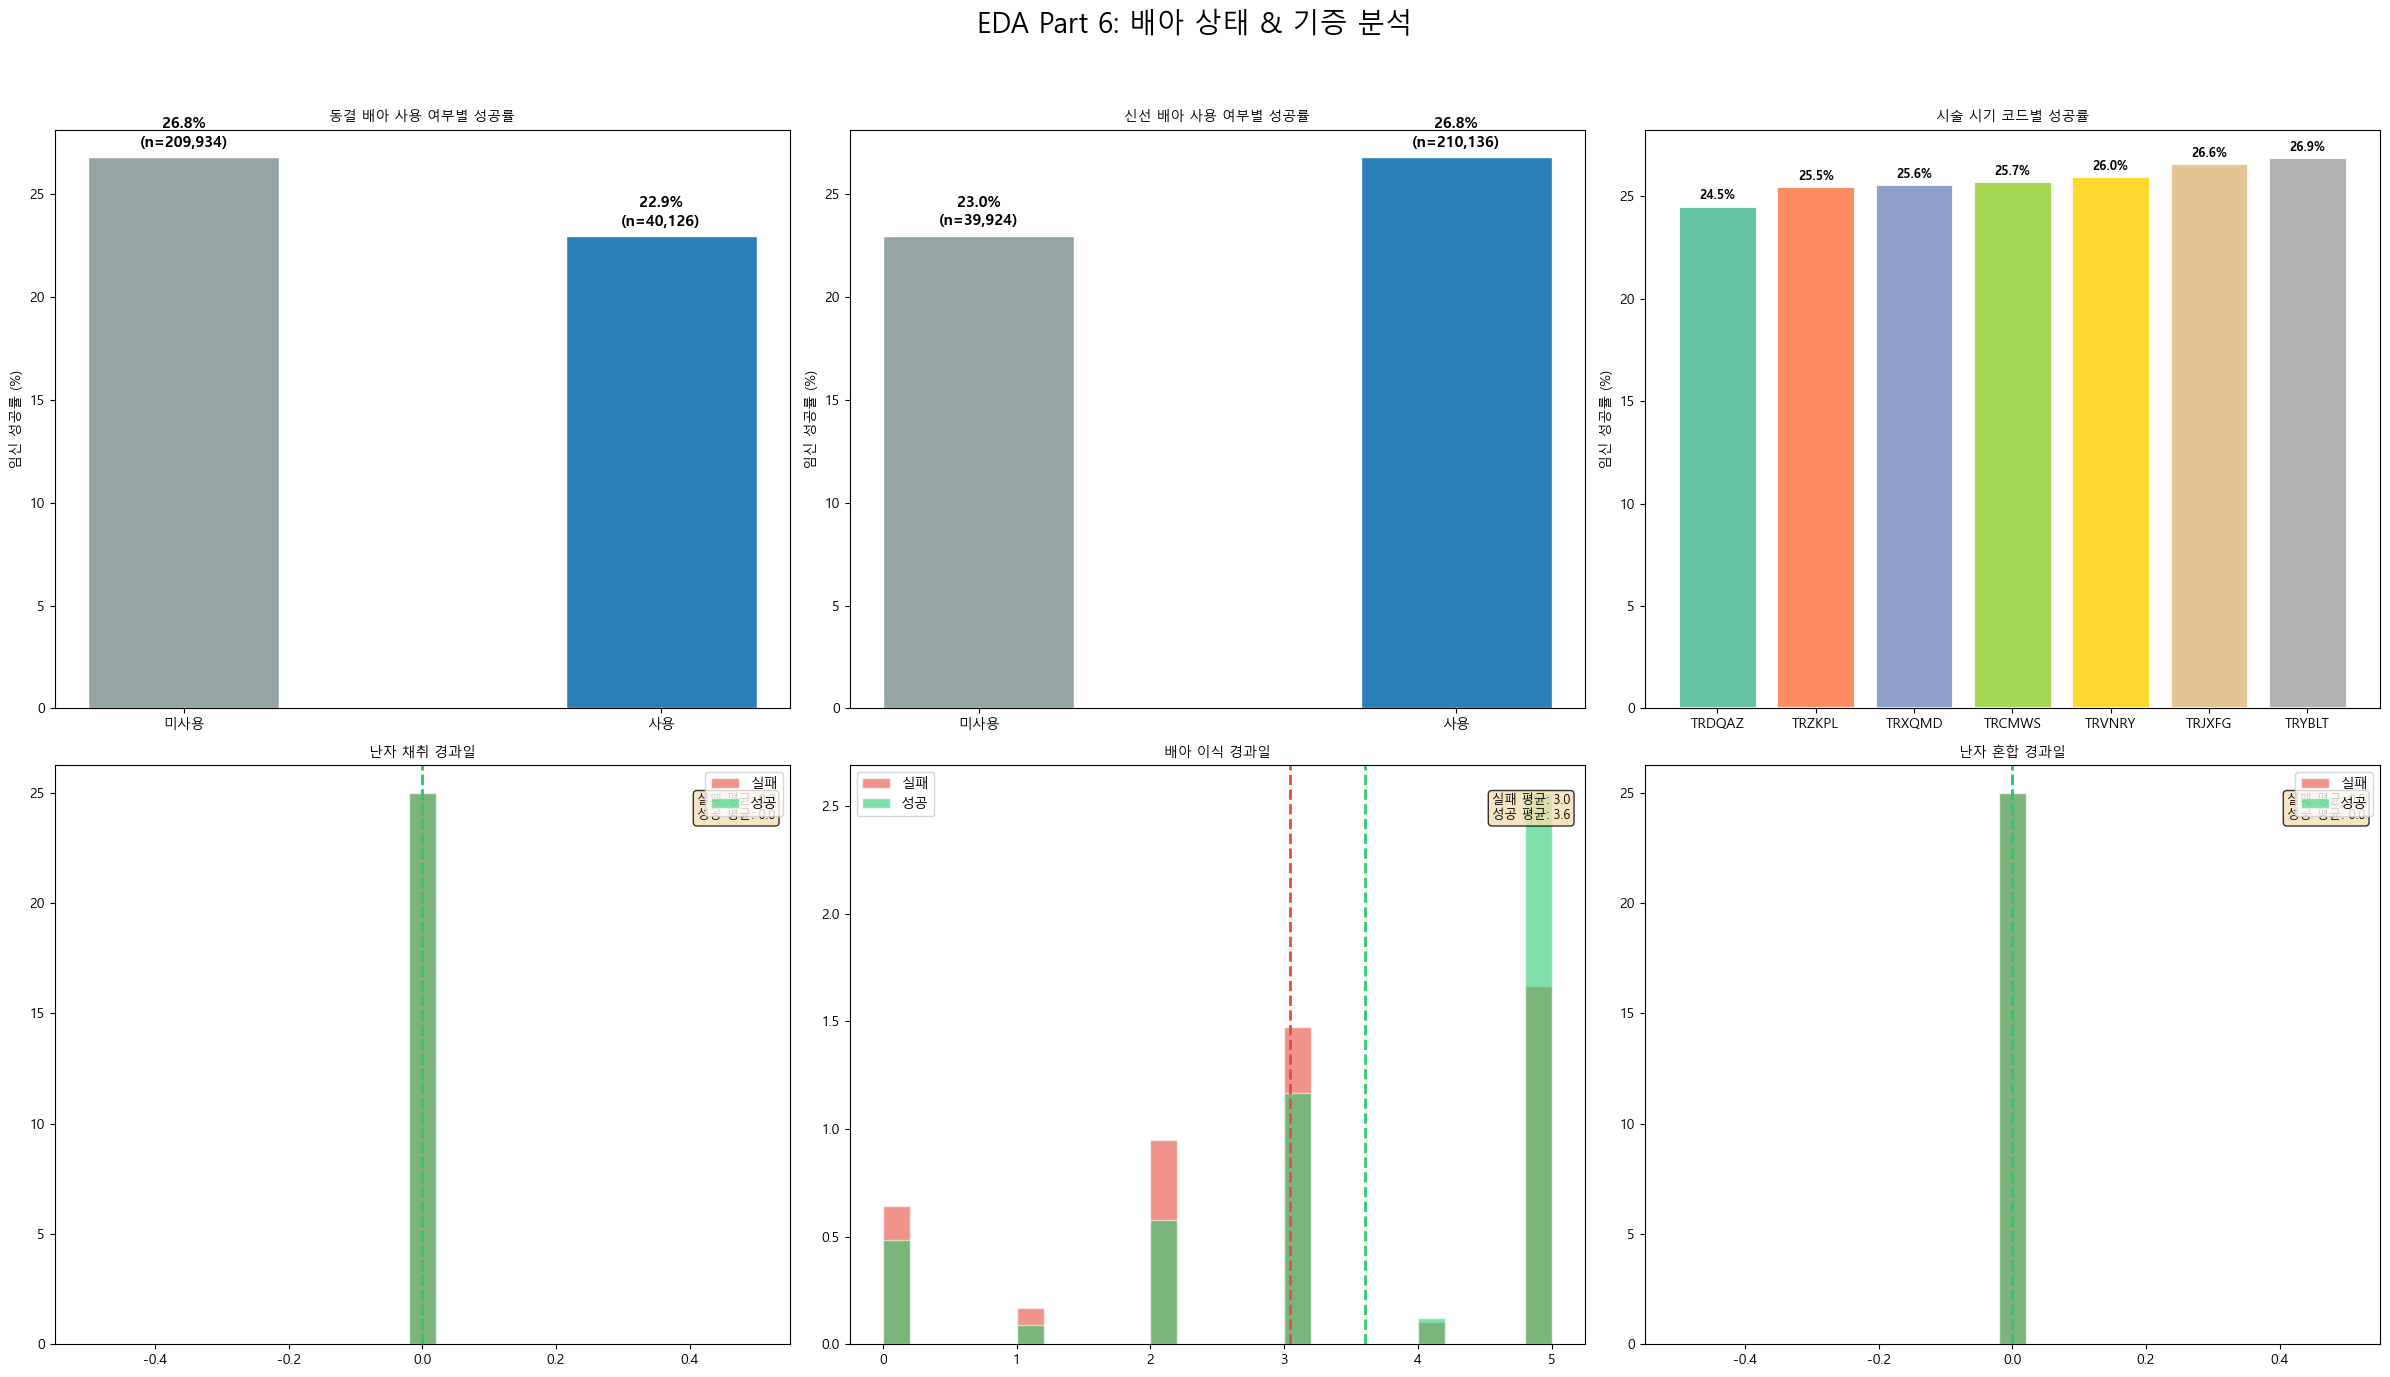

✅ Part 6 저장 완료


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle('EDA Part 6: 배아 상태 & 기증 분석', fontsize=20, fontweight='bold', **fp_kw)

# 8-1) 동결 배아 사용 여부
frozen_col = '동결 배아 사용 여부'
fresh_col = '신선 배아 사용 여부'

for i, (col, title) in enumerate([(frozen_col, '동결 배아'), (fresh_col, '신선 배아')]):
    if col in train.columns:
        data = train.groupby(col)[TARGET].agg(['mean', 'count']).dropna()
        labels = ['미사용', '사용']
        bars = axes[0, i].bar(labels[:len(data)], data['mean'] * 100,
                               color=['#95A5A6', '#2980B9'], edgecolor='white', width=0.4)
        axes[0, i].set_ylabel('임신 성공률 (%)', **fp_kw)
        axes[0, i].set_title(f'{title} 사용 여부별 성공률', fontsize=14, fontweight='bold', **fp_kw)
        for b, (idx, row) in zip(bars, data.iterrows()):
            axes[0, i].text(b.get_x() + b.get_width()/2, row['mean']*100 + 0.5,
                            f"{row['mean']*100:.1f}%\n(n={int(row['count']):,})",
                            ha='center', fontsize=11, fontweight='bold')

# 8-2) 시술 시기 코드별 성공률
time_col = '시술 시기 코드'
if time_col in train.columns:
    time_sr = train.groupby(time_col)[TARGET].agg(['mean', 'count']).sort_values('mean')
    bars = axes[0, 2].bar(time_sr.index, time_sr['mean'] * 100,
                           color=plt.cm.Set2(np.linspace(0, 1, len(time_sr))),
                           edgecolor='white', linewidth=2)
    axes[0, 2].set_ylabel('임신 성공률 (%)', **fp_kw)
    axes[0, 2].set_title('시술 시기 코드별 성공률', fontsize=14, fontweight='bold', **fp_kw)
    for b, (idx, row) in zip(bars, time_sr.iterrows()):
        axes[0, 2].text(b.get_x() + b.get_width()/2, row['mean']*100 + 0.3,
                        f"{row['mean']*100:.1f}%", ha='center', fontsize=9, fontweight='bold')

# 8-3) 경과일 변수 분포
elapsed_cols = ['난자 채취 경과일', '배아 이식 경과일', '난자 혼합 경과일']
el_exist = [c for c in elapsed_cols if c in train.columns]

for i, col in enumerate(el_exist[:3]):
    ax = axes[1, i]
    d0 = train[train[TARGET] == 0][col].dropna()
    d1 = train[train[TARGET] == 1][col].dropna()
    
    if len(d0) > 0 and len(d1) > 0:
        upper = train[col].quantile(0.95)
        d0 = d0[d0 <= upper]
        d1 = d1[d1 <= upper]
        
        ax.hist(d0, bins=25, alpha=0.6, color='#E74C3C', label='실패', density=True, edgecolor='white')
        ax.hist(d1, bins=25, alpha=0.6, color='#2ECC71', label='성공', density=True, edgecolor='white')
        ax.axvline(d0.mean(), color='#E74C3C', linestyle='--', lw=2)
        ax.axvline(d1.mean(), color='#2ECC71', linestyle='--', lw=2)
        ax.set_title(col, fontsize=12, fontweight='bold', **fp_kw)
        ax.legend(prop=fp if fp else {})
        ax.text(0.98, 0.95, f'실패 평균: {d0.mean():.1f}\n성공 평균: {d1.mean():.1f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), **fp_kw)
    else:
        ax.text(0.5, 0.5, f'{col}\n데이터 부족', transform=ax.transAxes,
                ha='center', va='center', fontsize=14, **fp_kw)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('eda_part6_frozen_donation.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Part 6 저장 완료")


## EDA Part 7 — 종합 인사이트 요약

In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('../data/train.csv')
TARGET = '임신 성공 여부'

# ============================================================
# 1. 데이터 개요
# ============================================================
print("=" * 60)
print("1. 데이터 개요")
print("=" * 60)
print(f"행: {train.shape[0]}, 열: {train.shape[1]}")
print(f"메모리: {train.memory_usage(deep=True).sum()/1024**2:.1f}MB")
print(f"중복행: {train.duplicated().sum()}")
print(f"object 컬럼: {train.select_dtypes('object').shape[1]}")
print(f"numeric 컬럼: {train.select_dtypes(np.number).shape[1]}")

# ============================================================
# 2. 타겟 분포
# ============================================================
print("\n" + "=" * 60)
print("2. 타겟 분포")
print("=" * 60)
vc = train[TARGET].value_counts()
print(f"실패(0): {vc[0]:,} ({vc[0]/len(train)*100:.1f}%)")
print(f"성공(1): {vc[1]:,} ({vc[1]/len(train)*100:.1f}%)")
print(f"불균형비: {vc[0]/vc[1]:.2f}:1")

# ============================================================
# 3. 결측치
# ============================================================
print("\n" + "=" * 60)
print("3. 결측치 (결측 있는 컬럼만)")
print("=" * 60)
miss = train.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)
print(f"결측 있는 컬럼: {len(miss)}개 / 전체 {train.shape[1]}개\n")
for col, cnt in miss.items():
    print(f"  {col}: {cnt:,} ({cnt/len(train)*100:.1f}%)")

# ============================================================
# 4. 범주형 변수별 성공률
# ============================================================
print("\n" + "=" * 60)
print("4. 범주형 변수별 성공률")
print("=" * 60)

cat_cols = train.select_dtypes('object').columns.tolist()
for col in cat_cols:
    if col == 'ID':
        continue
    print(f"\n--- {col} (고유값: {train[col].nunique()}) ---")
    grp = train.groupby(col)[TARGET].agg(['count', 'mean'])
    grp.columns = ['건수', '성공률']
    grp['성공률'] = (grp['성공률'] * 100).round(1)
    grp = grp.sort_values('건수', ascending=False)
    for val, row in grp.head(10).iterrows():
        print(f"  {str(val)[:35]}: {int(row['건수']):,}건, 성공률 {row['성공률']}%")
    if len(grp) > 10:
        print(f"  ... 외 {len(grp)-10}개")

# ============================================================
# 5. 이진 변수별 성공률 차이
# ============================================================
print("\n" + "=" * 60)
print("5. 이진 변수별 성공률 차이")
print("=" * 60)

results = []
for col in train.columns:
    if col in ['ID', TARGET]:
        continue
    vals = set(train[col].dropna().unique())
    if not vals.issubset({0, 1, 0.0, 1.0}):
        continue
    n0 = (train[col] == 0).sum()
    n1 = (train[col] == 1).sum()
    if n0 == 0 or n1 == 0:
        continue
    sr0 = train.loc[train[col] == 0, TARGET].mean() * 100
    sr1 = train.loc[train[col] == 1, TARGET].mean() * 100
    results.append({'col': col, 'n0': n0, 'n1': n1, 'sr0': sr0, 'sr1': sr1, 'diff': sr1 - sr0})

results = sorted(results, key=lambda x: abs(x['diff']), reverse=True)
print(f"총 {len(results)}개 이진 변수\n")
for r in results:
    print(f"  {r['col'][:40]}")
    print(f"    0: {r['n0']:,}건 성공률 {r['sr0']:.1f}% | 1: {r['n1']:,}건 성공률 {r['sr1']:.1f}% | 차이: {r['diff']:+.1f}%p")

# ============================================================
# 6. 순서형(횟수) 변수별 성공률
# ============================================================
print("\n" + "=" * 60)
print("6. 순서형(횟수) 변수별 성공률")
print("=" * 60)

count_cols = [c for c in train.columns if '횟수' in c]
for col in count_cols:
    print(f"\n--- {col} ---")
    grp = train.groupby(col)[TARGET].agg(['count', 'mean'])
    for val, row in grp.iterrows():
        print(f"  {val}: {int(row['count']):,}건, 성공률 {row['mean']*100:.1f}%")

# ============================================================
# 7. 수치형 변수 기초통계 + 성공/실패 비교
# ============================================================
print("\n" + "=" * 60)
print("7. 수치형 변수 기초통계 + 성공/실패 비교 (t-test)")
print("=" * 60)

num_cols = [
    '총 생성 배아 수', '미세주입된 난자 수', '미세주입에서 생성된 배아 수',
    '이식된 배아 수', '미세주입 배아 이식 수', '저장된 배아 수',
    '해동된 배아 수', '해동 난자 수', '수집된 신선 난자 수',
    '저장된 신선 난자 수', '혼합된 난자 수', '파트너 정자와 혼합된 난자 수',
    '기증자 정자와 혼합된 난자 수', '난자 채취 경과일', '난자 해동 경과일',
    '난자 혼합 경과일', '배아 이식 경과일', '배아 해동 경과일',
    '임신 시도 또는 마지막 임신 경과 연수'
]
num_exist = [c for c in num_cols if c in train.columns]

for col in num_exist:
    s = train[col].dropna()
    if len(s) == 0:
        continue
    d0 = train.loc[train[TARGET] == 0, col].dropna()
    d1 = train.loc[train[TARGET] == 1, col].dropna()
    
    sig = ''
    if len(d0) >= 10 and len(d1) >= 10:
        _, p = stats.ttest_ind(d0, d1, equal_var=False)
        if p < 0.001:
            sig = '***'
        elif p < 0.01:
            sig = '**'
        elif p < 0.05:
            sig = '*'
        else:
            sig = 'NS'
    
    print(f"\n--- {col} (결측: {train[col].isnull().sum():,}) ---")
    print(f"  전체: 평균={s.mean():.2f}, 중앙={s.median():.1f}, 표준편차={s.std():.2f}, 최소={s.min():.1f}, 최대={s.max():.1f}")
    if len(d0) > 0 and len(d1) > 0:
        print(f"  실패: 평균={d0.mean():.2f} | 성공: 평균={d1.mean():.2f} | 차이={d1.mean()-d0.mean():+.2f} | {sig}")

# ============================================================
# 8. 나이별 상세
# ============================================================
print("\n" + "=" * 60)
print("8. 나이별 상세")
print("=" * 60)

age_col = '시술 당시 나이'
if age_col in train.columns:
    age_order = ['만18-34세', '만35-37세', '만38-39세', '만40-42세', '만43-44세', '만45-50세', '알 수 없음']
    for age in age_order:
        mask = train[age_col] == age
        if mask.sum() == 0:
            continue
        n = mask.sum()
        sr = train.loc[mask, TARGET].mean() * 100
        n1 = train.loc[mask, TARGET].sum()
        print(f"  {age}: {n:,}건, 성공 {int(n1):,}건, 성공률 {sr:.1f}%")

# ============================================================
# 9. 불임 원인 분석
# ============================================================
print("\n" + "=" * 60)
print("9. 불임 원인 분석")
print("=" * 60)

inf_cols = [c for c in train.columns if '불임 원인 -' in c]
if inf_cols:
    print("\n[개별 불임 원인 빈도 & 성공률]")
    for col in inf_cols:
        n1 = int(train[col].sum())
        sr = train.loc[train[col] == 1, TARGET].mean() * 100 if n1 > 0 else 0
        short = col.replace('불임 원인 - ', '')
        print(f"  {short}: {n1:,}건 해당, 성공률 {sr:.1f}%")
    
    print("\n[불임 원인 개수별 성공률]")
    train['_inf_cnt'] = train[inf_cols].sum(axis=1)
    for cnt in sorted(train['_inf_cnt'].unique()):
        mask = train['_inf_cnt'] == cnt
        n = mask.sum()
        sr = train.loc[mask, TARGET].mean() * 100
        print(f"  {int(cnt)}개: {n:,}건, 성공률 {sr:.1f}%")
    
    print("\n[불임 원인 조합 Top 10]")
    train['_combo'] = train[inf_cols].apply(
        lambda r: '+'.join([c.replace('불임 원인 - ', '') for c, v in zip(inf_cols, r) if v == 1]) or '없음', axis=1
    )
    combo = train.groupby('_combo')[TARGET].agg(['count', 'mean']).sort_values('count', ascending=False).head(10)
    for val, row in combo.iterrows():
        print(f"  {val[:50]}: {int(row['count']):,}건, 성공률 {row['mean']*100:.1f}%")
    
    train.drop(columns=['_inf_cnt', '_combo'], inplace=True, errors='ignore')

# ============================================================
# 10. 난자/정자 출처
# ============================================================
print("\n" + "=" * 60)
print("10. 난자/정자 출처별 성공률")
print("=" * 60)

for col in ['난자 출처', '정자 출처']:
    if col not in train.columns:
        continue
    print(f"\n--- {col} ---")
    grp = train.groupby(col)[TARGET].agg(['count', 'mean'])
    for val, row in grp.iterrows():
        print(f"  {val}: {int(row['count']):,}건, 성공률 {row['mean']*100:.1f}%")

if '난자 출처' in train.columns and '정자 출처' in train.columns:
    print("\n--- 난자×정자 출처 조합 ---")
    combo = train.groupby(['난자 출처', '정자 출처'])[TARGET].agg(['count', 'mean'])
    combo = combo.sort_values('count', ascending=False)
    for (e, s), row in combo.iterrows():
        print(f"  {e} + {s}: {int(row['count']):,}건, 성공률 {row['mean']*100:.1f}%")

# ============================================================
# 11. 타겟 상관관계 Top 20
# ============================================================
print("\n" + "=" * 60)
print("11. 타겟 상관관계 Top 20")
print("=" * 60)

num_data = train.select_dtypes(np.number)
if TARGET in num_data.columns:
    corr = num_data.corr()[TARGET].drop(TARGET)
    top = corr.abs().sort_values(ascending=False).head(20)
    for col in top.index:
        r = corr[col]
        print(f"  {col[:45]}: {r:+.4f}")

# ============================================================
# 12. IVF vs DI 비교
# ============================================================
print("\n" + "=" * 60)
print("12. IVF vs DI 서브그룹 비교")
print("=" * 60)

if '시술 유형' in train.columns:
    for ptype in train['시술 유형'].unique():
        sub = train[train['시술 유형'] == ptype]
        print(f"\n--- {ptype} (n={len(sub):,}) ---")
        print(f"  성공률: {sub[TARGET].mean()*100:.1f}%")
        
        if age_col in sub.columns:
            mode_age = sub[age_col].mode()
            print(f"  최빈 나이: {mode_age.iloc[0] if len(mode_age) > 0 else 'N/A'}")
        
        sub_miss = (sub.isnull().sum() / len(sub) * 100)
        high = sub_miss[sub_miss > 50].sort_values(ascending=False)
        if len(high) > 0:
            print(f"  결측 50%이상 변수: {len(high)}개")
            for c, p in high.head(5).items():
                print(f"    {c}: {p:.1f}%")

# ============================================================
# 13. 이상치 탐지
# ============================================================
print("\n" + "=" * 60)
print("13. 이상치 탐지 (IQR 방식)")
print("=" * 60)

for col in num_exist:
    s = train[col].dropna()
    if len(s) < 10:
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue
    n_out = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()
    pct = n_out / len(s) * 100
    if n_out > 0:
        print(f"  {col[:40]}: {n_out:,}건 ({pct:.1f}%), 최대={s.max():.0f}")

# ============================================================
# 14. 배아 생성 이유별
# ============================================================
print("\n" + "=" * 60)
print("14. 배아 생성 주요 이유별 성공률")
print("=" * 60)

reason_col = '배아 생성 주요 이유'
if reason_col in train.columns:
    grp = train.groupby(reason_col)[TARGET].agg(['count', 'mean']).sort_values('count', ascending=False)
    for val, row in grp.iterrows():
        print(f"  {val}: {int(row['count']):,}건, 성공률 {row['mean']*100:.1f}%")

# ============================================================
# 15. 시술 시기 코드별
# ============================================================
print("\n" + "=" * 60)
print("15. 시술 시기 코드별 성공률")
print("=" * 60)

time_col = '시술 시기 코드'
if time_col in train.columns:
    grp = train.groupby(time_col)[TARGET].agg(['count', 'mean']).sort_values('mean', ascending=False)
    for val, row in grp.iterrows():
        print(f"  {val}: {int(row['count']):,}건, 성공률 {row['mean']*100:.1f}%")

# ============================================================
# 16. 동결/신선/기증 배아 사용별
# ============================================================
print("\n" + "=" * 60)
print("16. 동결/신선/기증 배아 사용 여부별 성공률")
print("=" * 60)

for col in ['동결 배아 사용 여부', '신선 배아 사용 여부', '기증 배아 사용 여부']:
    if col not in train.columns:
        continue
    print(f"\n--- {col} ---")
    grp = train.groupby(col)[TARGET].agg(['count', 'mean']).dropna()
    for val, row in grp.iterrows():
        label = '사용' if val == 1 else '미사용'
        print(f"  {label}: {int(row['count']):,}건, 성공률 {row['mean']*100:.1f}%")

# ============================================================
# 17. 종합 요약 (데이터 기반 자동 생성)
# ============================================================
print("\n" + "=" * 60)
print("17. 종합 요약 (데이터 기반)")
print("=" * 60)

# 기본 수치
print(f"\n전체 성공률: {train[TARGET].mean()*100:.1f}%")
print(f"불균형비: {vc[0]/vc[1]:.1f}:1")
print(f"결측 있는 변수: {len(miss)}개")

# 나이별 성공률 실제 계산
print("\n[나이별 성공률]")
age_col = '시술 당시 나이'
if age_col in train.columns:
    age_sr = train.groupby(age_col)[TARGET].mean().sort_values(ascending=False)
    for age, rate in age_sr.items():
        print(f"  {age}: {rate*100:.1f}%")
    print(f"  → 최고: {age_sr.idxmax()} ({age_sr.max()*100:.1f}%), 최저: {age_sr.idxmin()} ({age_sr.min()*100:.1f}%)")

# IVF vs DI 실제 계산
print("\n[시술 유형별 성공률]")
if '시술 유형' in train.columns:
    proc_sr = train.groupby('시술 유형')[TARGET].agg(['mean', 'count'])
    for ptype, row in proc_sr.iterrows():
        print(f"  {ptype}: {row['mean']*100:.1f}% ({int(row['count']):,}건)")

# 이식 배아 수별 실제 계산
print("\n[이식 배아 수별 성공률]")
emb_col = '이식된 배아 수'
if emb_col in train.columns:
    emb_data = train[train[emb_col].notna()].copy()
    emb_data['_emb_int'] = emb_data[emb_col].astype(int)
    emb_sr = emb_data.groupby('_emb_int')[TARGET].agg(['mean', 'count'])
    emb_sr = emb_sr[emb_sr['count'] >= 10]
    best_emb = emb_sr['mean'].idxmax()
    for val, row in emb_sr.iterrows():
        mark = ' ← 최고' if val == best_emb else ''
        print(f"  {val}개: {row['mean']*100:.1f}% ({int(row['count']):,}건){mark}")

# 동결 vs 신선 실제 계산
print("\n[동결 vs 신선 배아 성공률]")
for col in ['동결 배아 사용 여부', '신선 배아 사용 여부']:
    if col in train.columns:
        grp = train.groupby(col)[TARGET].mean().dropna()
        for val, rate in grp.items():
            label = '사용' if val == 1 else '미사용'
            print(f"  {col} {label}: {rate*100:.1f}%")

# 불임 원인 개수별 실제 계산
inf_cols = [c for c in train.columns if '불임 원인 -' in c]
if inf_cols:
    print("\n[불임 원인 개수별 성공률]")
    train['_inf_cnt'] = train[inf_cols].sum(axis=1)
    inf_sr = train.groupby('_inf_cnt')[TARGET].agg(['mean', 'count'])
    inf_sr = inf_sr[inf_sr['count'] >= 10]
    for cnt, row in inf_sr.iterrows():
        print(f"  {int(cnt)}개: {row['mean']*100:.1f}% ({int(row['count']):,}건)")
    train.drop(columns=['_inf_cnt'], inplace=True, errors='ignore')

# 상관관계 Top 5 실제 계산
print("\n[타겟 상관관계 Top 5]")
num_data = train.select_dtypes(np.number)
if TARGET in num_data.columns:
    corr = num_data.corr()[TARGET].drop(TARGET)
    top5 = corr.abs().sort_values(ascending=False).head(5)
    for i, col in enumerate(top5.index, 1):
        print(f"  {i}. {col}: {corr[col]:+.4f}")
    print(f"  → 가장 강한 변수: {top5.index[0]}")

# DI 결측 패턴 실제 확인
if '시술 유형' in train.columns:
    di_data = train[train['시술 유형'] == 'DI']
    if len(di_data) > 0:
        di_miss = (di_data.isnull().sum() / len(di_data) * 100)
        di_full_miss = di_miss[di_miss > 99].index.tolist()
        print(f"\n[DI 시술시 100% 결측 변수: {len(di_full_miss)}개]")
        for c in di_full_miss[:10]:
            print(f"  {c}")
        if len(di_full_miss) > 10:
            print(f"  ... 외 {len(di_full_miss)-10}개")

print("\n완료.")

1. 데이터 개요
행: 256351, 열: 69
메모리: 528.3MB
중복행: 0
object 컬럼: 21
numeric 컬럼: 48

2. 타겟 분포
실패(0): 190,123 (74.2%)
성공(1): 66,228 (25.8%)
불균형비: 2.87:1

3. 결측치 (결측 있는 컬럼만)
결측 있는 컬럼: 31개 / 전체 69개

  난자 해동 경과일: 254,915 (99.4%)
  PGS 시술 여부: 254,422 (99.2%)
  PGD 시술 여부: 254,172 (99.1%)
  착상 전 유전 검사 사용 여부: 253,633 (98.9%)
  임신 시도 또는 마지막 임신 경과 연수: 246,981 (96.3%)
  배아 해동 경과일: 215,982 (84.3%)
  난자 채취 경과일: 57,488 (22.4%)
  난자 혼합 경과일: 53,735 (21.0%)
  배아 이식 경과일: 43,566 (17.0%)
  총 생성 배아 수: 6,291 (2.5%)
  기증자 정자와 혼합된 난자 수: 6,291 (2.5%)
  단일 배아 이식 여부: 6,291 (2.5%)
  착상 전 유전 진단 사용 여부: 6,291 (2.5%)
  배아 생성 주요 이유: 6,291 (2.5%)
  대리모 여부: 6,291 (2.5%)
  기증 배아 사용 여부: 6,291 (2.5%)
  신선 배아 사용 여부: 6,291 (2.5%)
  동결 배아 사용 여부: 6,291 (2.5%)
  파트너 정자와 혼합된 난자 수: 6,291 (2.5%)
  미세주입된 난자 수: 6,291 (2.5%)
  혼합된 난자 수: 6,291 (2.5%)
  저장된 신선 난자 수: 6,291 (2.5%)
  해동 난자 수: 6,291 (2.5%)
  해동된 배아 수: 6,291 (2.5%)
  미세주입 후 저장된 배아 수: 6,291 (2.5%)
  저장된 배아 수: 6,291 (2.5%)
  미세주입 배아 이식 수: 6,291 (2.5%)
  이식된 배아 수: 6,291 (2.5%)
  미세주입에

In [31]:
result = train.groupby(train['배란 유도 유형'].isnull())['임신 성공 여부'].value_counts().unstack()

# 결과 보기 좋게 인덱스 이름 변경 (True -> 결측치, False -> 데이터 있음)
result.index = ['데이터 있음 (Not Null)', '결측치 (Null)']
print(result)

ValueError: Length mismatch: Expected axis has 1 elements, new values have 2 elements

임신 성공 여부                0      1
데이터 있음 (Not Null)    1570    609
결측치 (Null)         188553  65619

In [34]:
# 범주별로 임신 성공 여부(0, 1)의 개수를 표로 만듭니다.
age_analysis = pd.crosstab(train['남성 주 불임 원인'], train['임신 성공 여부'])

# 합계 컬럼을 추가해서 전체 데이터 양도 같이 봅니다.
age_analysis['전체'] = age_analysis.sum(axis=1)

# 성공률(%) 컬럼을 추가하면 비교가 더 쉽습니다.
age_analysis['성공률(%)'] = (age_analysis[1] / age_analysis['전체']) * 100

print(age_analysis.sort_values(by='전체', ascending=False))

임신 성공 여부         0      1      전체     성공률(%)
남성 주 불임 원인                                  
0           184421  64620  249041  25.947535
1             5702   1608    7310  21.997264


In [30]:
def group_methods(text):
    # 만약 데이터가 null(NaN)이거나 문자열이 아니면 'Unknown' 반환
    if pd.isna(text) or not isinstance(text, str):
        return 'Unknown_Type'
    
    if 'BLASTOCYST' in text: 
        return 'High_Success_Group'
    if ':' in text and ('ICSI' in text or 'IVF' in text): 
        return 'Repeat_or_Complex'
    if text in ['GIFT', 'FER', 'IVI', 'ICI']: 
        return 'Rare_Type'
    
    return text

# 적용할 때 데이터프레임이 'train'이라고 가정합니다.
import pandas as pd
train['시술_그룹'] = train['특정 시술 유형'].apply(group_methods)
